# Wedding Recall Data, Manning Topic Model Pipeline

In [1]:
import os
import pdb
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
import nltk
import brainiak.eventseg.event

# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = stopwords.words('english')
# from topic_model_pipeline import train_and_getLDA_topic_model
# from topic_model_pipeline import put_same_event_labels_together
# from topic_model_pipeline import *

# import warnings
# import sys
# import os    
# # import logging

# import deepdish as dd
# import numpy as np
# import hypertools as hyp

# import brainiak.eventseg.event

# import scipy.io
# from scipy import stats
# from scipy.stats import norm, zscore, pearsonr
# from scipy.signal import gaussian, convolve
# from sklearn import decomposition
# from sklearn.model_selection import LeaveOneOut, KFold
# from plotnine import ggplot, geom_label, geom_point, aes, ggtitle, geom_text, stat_smooth, facet_wrap, geom_boxplot, geom_histogram, xlim, ylim, facet_grid

# from matplotlib import pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import matplotlib.patches as patches
# import seaborn as sns 


ModuleNotFoundError: No module named 'brainiak'

In [ ]:
perceived_window_size = 10
recall_window_size = 5
perceived_k_range = range(2,50)
recall_k_range = range(2,30)
step_var_scale = 4
penalty_parameter = 0
event_seg_type = "gsbs"

# Train LDA model, Get Vectorizer, Get Topic Proportions and Sliding Windows for each Wedding and each Event Segment ID in Perceived Narrations

In [18]:
lda, vectorizer, word_count_matrix, wedding_id_to_segment_id_to_sliding_windows_dict, wedding_id_to_segment_id_to_embedding_dict, list_of_bags, list_of_segment_id, narrative_id = train_and_getLDA_topic_model(num_components = 300, perceived_window_size = perceived_window_size, recall_window_size = recall_window_size)

In [19]:
%store lda
%store vectorizer
%store word_count_matrix
%store wedding_id_to_segment_id_to_sliding_windows_dict
%store wedding_id_to_segment_id_to_embedding_dict
%store list_of_segment_id

Stored 'lda' (LatentDirichletAllocation)
Stored 'vectorizer' (CountVectorizer)
Stored 'word_count_matrix' (ndarray)
Stored 'wedding_id_to_segment_id_to_sliding_windows_dict' (dict)
Stored 'wedding_id_to_segment_id_to_embedding_dict' (dict)
Stored 'list_of_segment_id' (list)


In [20]:
%store -r
%store -r lda
%store -r vectorizer
%store -r word_count_matrix
%store -r wedding_id_to_segment_id_to_sliding_windows_dict
%store -r wedding_id_to_segment_id_to_embedding_dict

In [21]:
embedding_list = []
for wedding in wedding_id_to_segment_id_to_embedding_dict:
    for segment_id in wedding_id_to_segment_id_to_embedding_dict[wedding]:
        for embedding in  wedding_id_to_segment_id_to_embedding_dict[wedding][segment_id]:
            embedding_list.append(embedding[0])
narration_matrix = np.vstack(embedding_list)
            
len(narrative_id)


4599

In [22]:
# # Make correlation plot
# f, ax = plt.subplots(1,1, figsize = (10,8))
# img = ax.imshow(np.corrcoef(narration_matrix), cmap='viridis')
# title_text = '''
# Segment-Segment correlation matrix
# '''
# f.colorbar(img)
# ax.set_title(title_text)
# ax.set_xlabel('Segment')
# ax.set_ylabel('Segment')

/Users/rosskempner/opt/anaconda3/envs/mybrainiak/lib/python3.6/site-packages/hypertools/plot/plot.py:509: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray


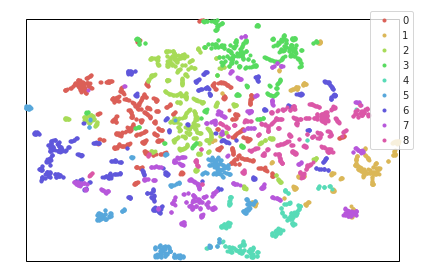

In [23]:
hyp.plot(narration_matrix, fmt = ".", hue = list_of_segment_id, reduce='TSNE', ndims = 2, legend = [0,1,2,3,4,5,6,7,8])

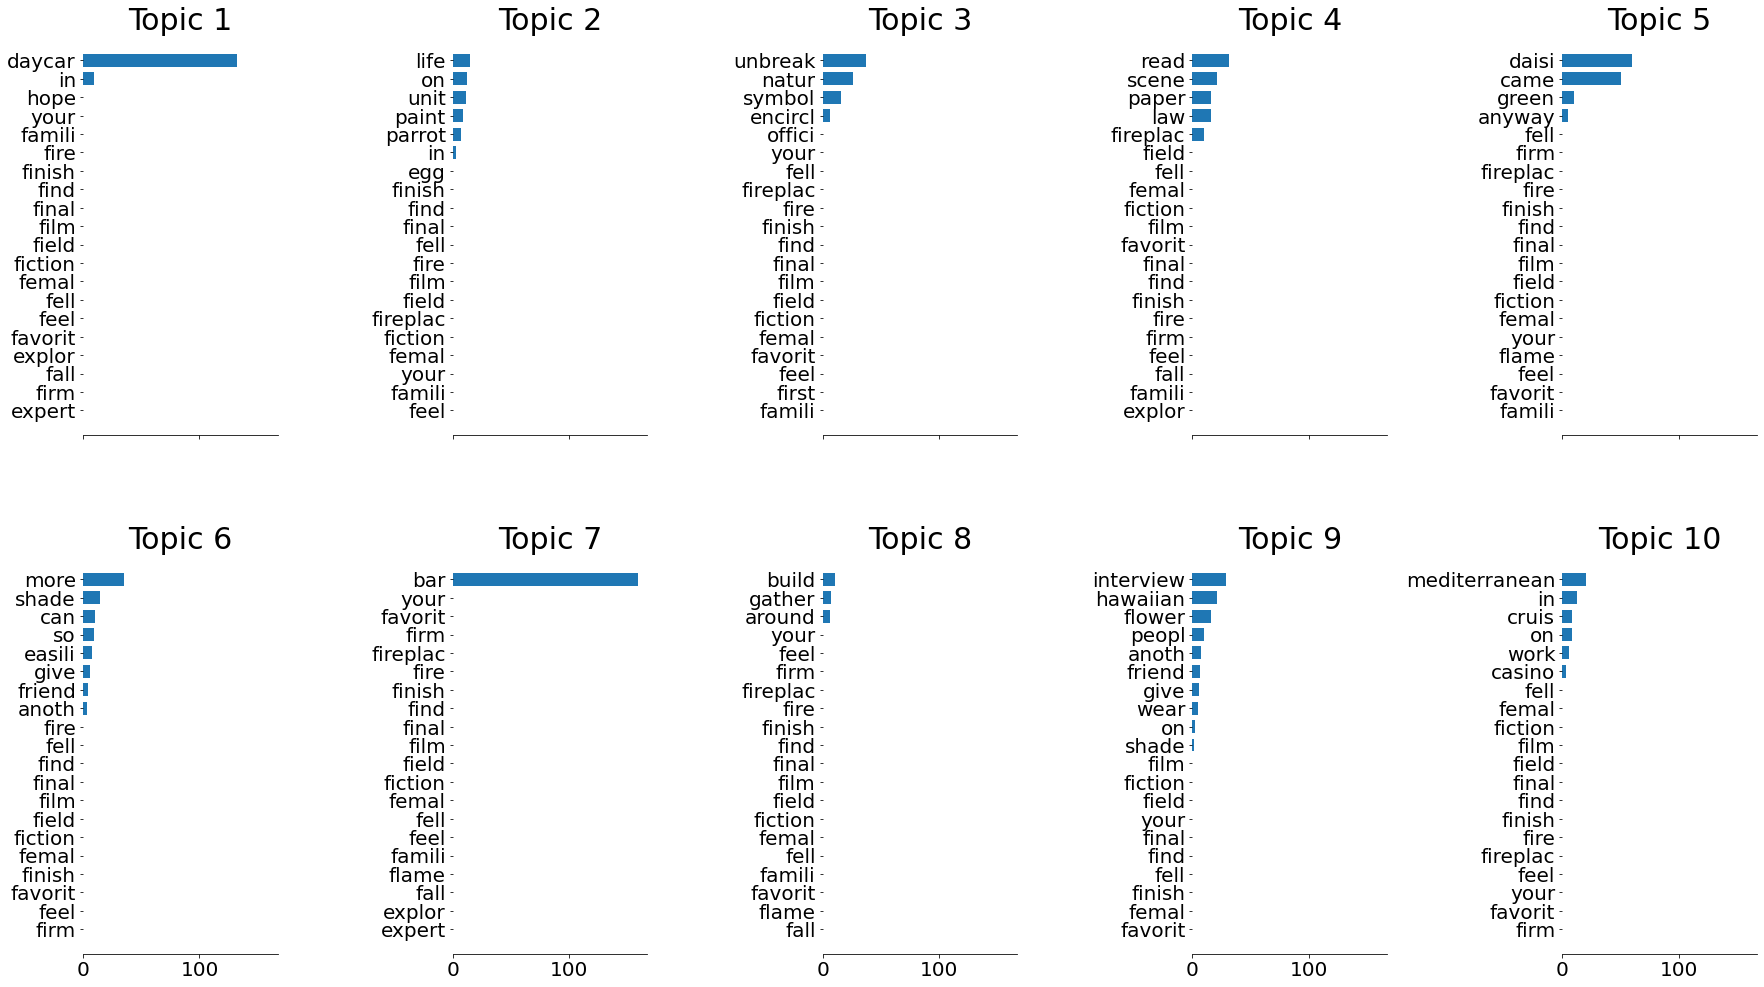

In [24]:
# here do the correlations between the perceived and the recalled
plot_model_topics(lda, vectorizer, n_top_words = 20, title = "")
#lda.components_.shape

In [25]:
# before = vectorizer.get_feature_names()
# %store -r before
# stop_words

In [26]:
# def build_tokenizer():
#     token_pattern = re.compile(r"(?u)\b\S+\b")
#     if token_pattern.groups > 1:
#         raise ValueError(
#             "More than 1 capturing group in token pattern. Only a single "
#             "group should be captured."
#         )

#     return token_pattern.findall
# tokenizer = build_tokenizer()
# tokens = [tokenizer(w) for w in stop_words]
# tokens


In [27]:
# vectorizer.get_stop_words()

In [28]:
w = "dave"
ws = stemmer.stem(w)

In [29]:
after = vectorizer.get_feature_names()
#print(w in after, ws in after)
len(after)


939

# Perceived Weddings: Now get the topic vector for each event in a segment in all weddings and segments

In [4]:
#new_dict = {28: {0: wedding_id_to_segment_id_to_embedding_dict[28][0]}}
#new_dict = {28: wedding_id_to_segment_id_to_embedding_dict[28]}
new_dict = wedding_id_to_segment_id_to_embedding_dict

In [5]:
wedding_to_segment_to_event_topic_vectors, all_optimal_K_list,  perceived_wedding_to_segment_to_wasser_list = get_perceived_event_topic_vectors(event_seg_type, new_dict, step_var_scale = step_var_scale, penalty_parameter = penalty_parameter, k_range = perceived_k_range)

17 0
17 1
17 2
17 3
17 4
17 5
17 6
17 7
17 8
19 0
19 1
19 2
19 3
19 4
19 5
19 6
19 7
19 8
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
20 0
20 1
20 2
20 3
20 4
20 5
20 6
20 7
20 8
22 0
22 1
22 2
22 3
22 4
22 5
22 6
22 7
22 8
23 0
23 1
23 2
23 3
23 4
23 5
23 6
23 7
23 8
28 0
28 1
> /Users/rosskempner/Desktop/Documents/Research/compmem/wedding_memory/code/python/topic_model_pipeline.py(725)gsbs_fitting()
    723     if wedding_id == 28 and segment_id == 1:
    724         pdb.set_trace()
--> 725     embeddings_matrix = np.vstack(embeddings)
    726     gsbs_sim = GSBS(x = embeddings_matrix, kmax = kmax)
    727     gsbs_sim.fit()

ipdb> c
28 2
28 3
28 4
28 5
28 6
28 7
28 8
29 0
29 1
29 2
29 3
29 4
29 5
29 6
29 7
29 8
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
34 0
34 1
34 2
34 3
34 4
34 5
34 6
34 7
34 8
38 0
38 1
38 2
38 3
38 4
38 5
38 6
38 7
38 8
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8


In [6]:
%store wedding_to_segment_to_event_topic_vectors
%store all_optimal_K_list
%store perceived_wedding_to_segment_to_wasser_list

Stored 'wedding_to_segment_to_event_topic_vectors' (dict)
Stored 'all_optimal_K_list' (list)
Stored 'perceived_wedding_to_segment_to_wasser_list' (dict)


In [7]:
%store -r wedding_to_segment_to_event_topic_vectors
%store -r all_optimal_K_list
%store -r perceived_wedding_to_segment_to_wasser_list

9

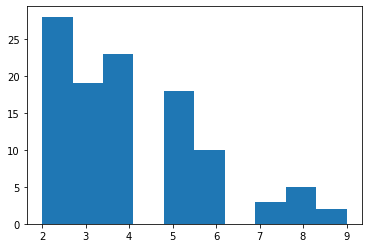

In [8]:
plt.hist(all_optimal_K_list)
max(all_optimal_K_list)

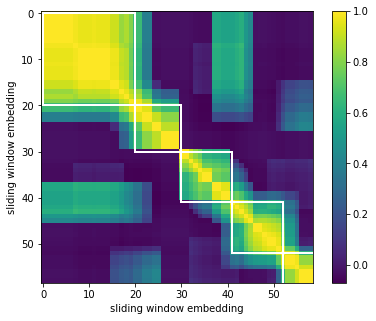

In [9]:
wedding = 28
segment = 8
_, bounds = perceived_get_event_segmented_embedding_matrix_and_bounds(wedding_to_segment_to_event_topic_vectors, wed_id = wedding, seg_id = segment)
matrix, T = get_topic_vector_matrix(wedding_id_to_segment_id_to_embedding_dict, wed_id = wedding, seg_id = segment)


plot_tt_similarity_matrix(matrix, bounds, T, title_text = "")

In [10]:
k_list = [x for x in range(2, len(perceived_wedding_to_segment_to_wasser_list[wedding][segment]) + 2)]
wasser_list = perceived_wedding_to_segment_to_wasser_list[wedding][segment]
plt.scatter(k_list,wasser_list)

TypeError: object of type 'NoneType' has no len()

In [11]:
def get_event_to_sliding_windows(wedding_to_segment_to_event_topic_vectors, 
                                    wedding_id_to_segment_id_to_sliding_windows_dict):
    wedding_to_segment_to_event_to_sliding_windows = {}
    for wedding_id in wedding_to_segment_to_event_topic_vectors:
        wedding_to_segment_to_event_to_sliding_windows[wedding_id] = {}
        for segment_id in wedding_to_segment_to_event_topic_vectors[wedding_id]:
            wedding_to_segment_to_event_to_sliding_windows[wedding_id][segment_id] = {}
            # get the bounds on the events for this wedding and segment
            bounds = wedding_to_segment_to_event_topic_vectors[wedding_id][segment_id]["bounds"]
            # traverse through each event in this wedding and segment
            for index,embedding in enumerate(wedding_to_segment_to_event_topic_vectors[wedding_id][segment_id]["embeddings"]):
                event_id = index
                # add all sliding windows in this event to dict
                this_wed_event_wndw = []
                lower_bound = bounds[index]
                lower_bound += 1 
                upper_bound = bounds[index + 1] + 1
                this_wed_event_wndw = [x[0] for x in wedding_id_to_segment_id_to_sliding_windows_dict[wedding_id][segment_id][lower_bound:upper_bound]]
                wedding_to_segment_to_event_to_sliding_windows[wedding_id][segment_id][event_id] = this_wed_event_wndw 
    return wedding_to_segment_to_event_to_sliding_windows


wedding_to_segment_to_event_to_sliding_windows = get_event_to_sliding_windows(wedding_to_segment_to_event_topic_vectors, 
                                    wedding_id_to_segment_id_to_sliding_windows_dict)

wedding_to_segment_to_event_to_sliding_windows[wedding][segment]

{0: ['shannon and tobia rejoic becaus their',
  'shannon and tobia rejoic becaus their friend',
  'shannon and tobia rejoic becaus their friend gave',
  'shannon and tobia rejoic becaus their friend gave them',
  'shannon and tobia rejoic becaus their friend gave them gift',
  'shannon and tobia rejoic becaus their friend gave them gift they',
  'and tobia rejoic becaus their friend gave them gift they receiv',
  'tobia rejoic becaus their friend gave them gift they receiv from',
  'rejoic becaus their friend gave them gift they receiv from one',
  'becaus their friend gave them gift they receiv from one friend',
  'their friend gave them gift they receiv from one friend a',
  'friend gave them gift they receiv from one friend a bottl',
  'gave them gift they receiv from one friend a bottl of',
  'them gift they receiv from one friend a bottl of glue',
  'gift they receiv from one friend a bottl of glue to',
  'they receiv from one friend a bottl of glue to use',
  'receiv from one fri

### Get Recall and Perceived Embeddings Matrix for a Participant

In [23]:
recall_embeddings_for_this_wedding, perceived_embedding_matrix, recall_wedding_to_embeddings, recall_wedding_to_sliding_windows, wedding_to_order = get_embeddings_matrices_for_participant_and_wedding_id(participant_id = 3, 
    wedding_id = 1, recall_window_size = recall_window_size, 
    lda_model = lda, vectorizer = vectorizer, 
    wedding_to_segment_to_sliding_windows = wedding_id_to_segment_id_to_sliding_windows_dict,
    wedding_to_segment_to_embeddings = wedding_id_to_segment_id_to_embedding_dict)

In [24]:
recall_wedding_to_event_topic_vectors, all_optimal_K_list, wedding_to_wasser_list, wedding_to_hmm = get_recall_event_topic_vectors(event_seg_type, recall_wedding_to_embeddings, k_range = recall_k_range, penalty_parameter = penalty_parameter, step_var = create_custom_step_var(step_var_scale))

22 None
19 None
38 None
20 None
1 None
6 None
23 None
28 None
34 None
17 None
2 None
29 None


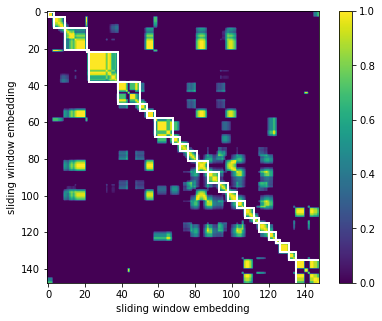

In [38]:
wedding = 38
_, bounds = recall_get_event_segmented_embedding_matrix_and_bounds(recall_wedding_to_event_topic_vectors, wed_id = wedding)
matrix, T = recall_get_topic_vector_matrix(recall_wedding_to_embeddings, wed_id = wedding)
plot_tt_similarity_matrix(matrix, bounds, T, title_text = "")


In [126]:
get_event_embeddings_for_all_perceived(wedding_to_segment_to_event_topic_vectors, 
                                    wedding_id_to_segment_id_to_sliding_windows_dict, 
                                    wedding_to_order)

(array([[0.0048    , 0.45635036, 0.0048    , ..., 0.0048    , 0.0048    ,
         0.0048    ],
        [0.0032619 , 0.27555953, 0.0032619 , ..., 0.0032619 , 0.0032619 ,
         0.0032619 ],
        [0.00242063, 0.05131449, 0.00242063, ..., 0.00242063, 0.00242063,
         0.00242063],
        ...,
        [0.00414881, 0.00414881, 0.00414881, ..., 0.00414881, 0.00414881,
         0.00414881],
        [0.00198632, 0.00198632, 0.00694358, ..., 0.00198632, 0.00198632,
         0.00198632],
        [0.00237324, 0.00237324, 0.01635925, ..., 0.00237324, 0.00237324,
         0.00237324]]),
 [(22, 0, 0),
  (22, 0, 1),
  (22, 0, 2),
  (22, 0, 3),
  (22, 0, 4),
  (22, 0, 5),
  (22, 0, 6),
  (22, 0, 7),
  (22, 0, 8),
  (22, 0, 9),
  (22, 0, 10),
  (22, 0, 11),
  (22, 1, 0),
  (22, 1, 1),
  (22, 3, 0),
  (22, 3, 1),
  (22, 3, 2),
  (22, 3, 3),
  (22, 3, 4),
  (22, 3, 5),
  (22, 5, 0),
  (22, 5, 1),
  (22, 7, 0),
  (22, 7, 1),
  (22, 7, 2),
  (22, 7, 3),
  (22, 8, 0),
  (22, 8, 1),
  (22, 8, 2),
 

In [134]:
p_r_aligned,wedding_segment_and_eventid_list, perceived_wedding_to_segment_to_event_to_sliding_windows, recall_wedding_to_event_to_sliding_windows, recall_wed_to_event_to_best_matches = align_perceived_and_recall_event_embeds(wedding_to_segment_to_event_topic_vectors, 
                                    wedding_id_to_segment_id_to_sliding_windows_dict, 
                                    wedding_to_order, recall_wedding_to_event_topic_vectors,
                                                     recall_wedding_to_sliding_windows,
                                                     best_matches_threshold = 0.5,
                                                     only_correct_perceived = True)

Text(0.5, 1.0, '')

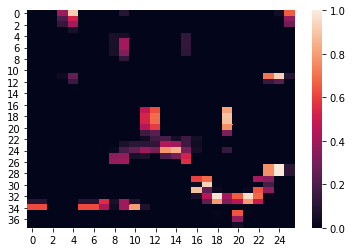

In [135]:
sns.heatmap(pd.DataFrame(p_r_aligned[34]), vmin=0, vmax=1).set_title("")

In [136]:
perceived_wedding_to_segment_to_event_to_sliding_windows[34]

{0: {0: ['denni and vivian met onlin they are both',
   'denni and vivian met onlin they are both movi'],
  1: ['denni and vivian met onlin they are both movi enthusiast',
   'denni and vivian met onlin they are both movi enthusiast and',
   'denni and vivian met onlin they are both movi enthusiast and went',
   'denni and vivian met onlin they are both movi enthusiast and went to',
   'denni and vivian met onlin they are both movi enthusiast and went to the'],
  2: ['denni and vivian met onlin they are both movi enthusiast and went to the theater',
   'and vivian met onlin they are both movi enthusiast and went to the theater for',
   'vivian met onlin they are both movi enthusiast and went to the theater for their',
   'met onlin they are both movi enthusiast and went to the theater for their first'],
  3: ['onlin they are both movi enthusiast and went to the theater for their first date',
   'they are both movi enthusiast and went to the theater for their first date they'],
  4: ['a

In [137]:
recall_wedding_to_event_to_sliding_windows[34]


{0: ['vivian and denni', 'vivian and denni they', 'vivian and denni they are'],
 1: ['and denni they are not', 'denni they are not the'],
 2: ['they are not the cruis',
  'are not the cruis ship',
  'not the cruis ship coupl'],
 3: ['the cruis ship coupl no',
  'cruis ship coupl no they',
  'ship coupl no they met',
  'coupl no they met onlin',
  'no they met onlin that'],
 4: ['they met onlin that is',
  'met onlin that is what',
  'onlin that is what it'],
 5: ['that is what it wa', 'is what it wa they'],
 6: ['what it wa they are'],
 7: ['it wa they are film',
  'wa they are film lover',
  'they are film lover and',
  'are film lover and they',
  'film lover and they got'],
 8: ['lover and they got togeth',
  'and they got togeth and',
  'they got togeth and start',
  'got togeth and start a'],
 9: ['togeth and start a film',
  'and start a film blog',
  'start a film blog togeth',
  'a film blog togeth and',
  'film blog togeth and fell'],
 10: ['blog togeth and fell in',
  'togeth

In [138]:
recall_wedding_to_event_to_sliding_windows[20]

{0: ['camil and felix', 'camil and felix met'],
 1: ['camil and felix met while',
  'and felix met while backpack',
  'felix met while backpack in'],
 2: ['met while backpack in brazil',
  'while backpack in brazil and',
  'backpack in brazil and chang',
  'in brazil and chang their',
  'brazil and chang their backpack',
  'and chang their backpack trip'],
 3: ['chang their backpack trip to',
  'their backpack trip to hike',
  'backpack trip to hike togeth',
  'trip to hike togeth they'],
 4: ['to hike togeth they are',
  'hike togeth they are from',
  'togeth they are from the'],
 5: ['they are from the north',
  'are from the north they',
  'from the north they are',
  'the north they are I',
  'north they are I dont'],
 6: ['they are I dont know',
  'are I dont know if',
  'I dont know if their',
  'dont know if their present',
  'know if their present wa',
  'if their present wa someth'],
 7: ['their present wa someth to',
  'present wa someth to keep',
  'wa someth to keep their',

In [139]:
recall_wed_to_event_to_best_matches[34][5]

array([34])

In [141]:
[(index,x) for index,x in enumerate(wedding_segment_and_eventid_list[34]) if index in recall_wed_to_event_to_best_matches[34][14] ]


#[(index,x) for index,x in enumerate(wedding_segment_and_eventid_list[20])]


[(24, (34, 3, 8))]

In [303]:
perceived_wedding_to_segment_to_event_to_sliding_windows[1][0]

{0: ['after 3 year',
  'after 3 year of',
  'after 3 year of date',
  '3 year of date jolen',
  'year of date jolen and',
  'of date jolen and jeffrey'],
 1: ['date jolen and jeffrey are',
  'jolen and jeffrey are get',
  'and jeffrey are get marri',
  'jeffrey are get marri they'],
 2: ['are get marri they met',
  'get marri they met in',
  'marri they met in ireland',
  'they met in ireland 3',
  'met in ireland 3 year',
  'in ireland 3 year ago'],
 3: ['ireland 3 year ago when',
  '3 year ago when they',
  'year ago when they were',
  'ago when they were both',
  'when they were both backpack'],
 4: ['they were both backpack around',
  'were both backpack around europ',
  'both backpack around europ they',
  'backpack around europ they enjoy',
  'around europ they enjoy each'],
 5: ['europ they enjoy each other',
  'they enjoy each other compani',
  'enjoy each other compani so',
  'each other compani so much',
  'other compani so much they',
  'compani so much they decid',
  'so mu

Text(0.5, 1.0, '')

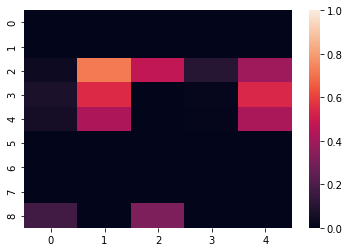

In [304]:
# get a mismatch !!!!!!!!
perceived_mismatch = 28
mismatch_seg = 2
recall_wed_mismatch = 28
all_p_r_aligned,all_wedding_segment_and_eventid_list, perceived_wedding_to_segment_to_event_to_sliding_windows, recall_wedding_to_event_to_sliding_windows, recall_wed_to_event_to_best_matches = align_perceived_and_recall_event_embeds(wedding_to_segment_to_event_topic_vectors, 
                                    wedding_id_to_segment_id_to_sliding_windows_dict, 
                                    wedding_to_order, recall_wedding_to_event_topic_vectors,
                                                     recall_wedding_to_sliding_windows,
                                                     best_matches_threshold = 0.5,
                                                     only_correct_perceived = False)
# get indices of all rows which have the perceived wedding and segment
perceived_indices = [index for index,x in enumerate(all_wedding_segment_and_eventid_list) if x[0] == perceived_mismatch and x[1] == mismatch_seg]
lower = perceived_indices[0]
upper = perceived_indices[-1] + 1
mismatch_p_r_aligned = all_p_r_aligned[recall_wed_mismatch][lower:upper,:]
mismatch_wed_seg_event_list = all_wedding_segment_and_eventid_list[lower:upper]


sns.heatmap(pd.DataFrame(mismatch_p_r_aligned), vmin=0, vmax=1).set_title("")

In [305]:
#get_corr_between_two_windows(lda, vectorizer, w1 = 'at a book meet', w2 = 'to combin their trip and backpack togeth today is their wed')
get_corr_between_two_windows(lda, vectorizer, w1 = 'hope  ', w2 = ' gun')

(-0.02040816326530611, 0.8881289642599198)

In [306]:
perceived_wedding_to_segment_to_event_to_sliding_windows[28][2]

{0: ['In the first',
  'In the first ritual',
  'In the first ritual tobia',
  'the first ritual tobia goe'],
 1: ['first ritual tobia goe out',
  'ritual tobia goe out and',
  'tobia goe out and get',
  'goe out and get a',
  'out and get a campfir',
  'and get a campfir and'],
 2: ['get a campfir and start',
  'a campfir and start a',
  'campfir and start a flame',
  'and start a flame him',
  'start a flame him and'],
 3: ['a flame him and shannon',
  'flame him and shannon gather',
  'him and shannon gather around',
  'and shannon gather around the',
  'shannon gather around the flame',
  'gather around the flame and',
  'around the flame and thi'],
 4: ['the flame and thi is',
  'flame and thi is meant',
  'and thi is meant to',
  'thi is meant to symbol'],
 5: ['is meant to symbol how',
  'meant to symbol how they',
  'to symbol how they will',
  'symbol how they will alway',
  'how they will alway appreci',
  'they will alway appreci their',
  'will alway appreci their love',
  

In [307]:
recall_wedding_to_event_to_sliding_windows[28]

{0: ['these guy were',
  'these guy were law',
  'these guy were law professor',
  'guy were law professor they',
  'were law professor they met',
  'law professor they met at',
  'professor they met at a',
  'they met at a dinner',
  'met at a dinner parti',
  'at a dinner parti they',
  'a dinner parti they lit',
  'dinner parti they lit a',
  'parti they lit a fire'],
 1: ['they lit a fire at',
  'lit a fire at the',
  'a fire at the ceremoni',
  'fire at the ceremoni becaus',
  'at the ceremoni becaus they',
  'the ceremoni becaus they studi',
  'ceremoni becaus they studi or'],
 2: ['becaus they studi or work',
  'they studi or work on',
  'studi or work on their',
  'or work on their stuff',
  'work on their stuff by',
  'on their stuff by fireplac',
  'their stuff by fireplac I',
  'stuff by fireplac I want',
  'by fireplac I want to',
  'fireplac I want to say',
  'I want to say they',
  'want to say they broke'],
 3: ['to say they broke an',
  'say they broke an egg',
  'they 

# all participants metrics


--------
p_id:  2
34 None
29 None
22 None
28 None
17 None
38 None
6 None
1 None
19 None
20 None
2 None
23 None
--------
p_id:  3
22 None
19 None
38 None
20 None
1 None
6 None
23 None
28 None
34 None
17 None
2 None
29 None
--------
p_id:  4
19 None
34 None
1 None
23 None
38 None
22 None
28 None
29 None
6 None
17 None
20 None
2 None
--------
p_id:  5
20 None
38 None
28 None
19 None
2 None
23 None
34 None
1 None
17 None
22 None
29 None
6 None
--------
p_id:  6
34 None
23 None
6 None
20 None
17 None
22 None
1 None
19 None
38 None
28 None
29 None
2 None
--------
p_id:  7
1 None
34 None
20 None
22 None
38 None
23 None
29 None
28 None
6 None
2 None
19 None
17 None
--------
p_id:  8
1 None
20 None
29 None
38 None
6 None
2 None
28 None
23 None
17 None
34 None
19 None
22 None
--------
p_id:  9
6 None
17 None
20 None
22 None
19 None
34 None
1 None
23 None
29 None
28 None
38 None
2 None
--------
p_id:  10
38 None
22 None
2 None
29 None
34 None
20 None
17 None
23 None
19 None
6 None
1 None
28 None


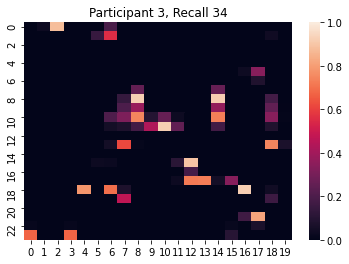

In [14]:
p_id_list = [2,3,4,5,6,7,8,9,10,11,12,13, 14, 15, 17, 18, 19, 22, 23, 24, 25, 26,27, 28, 29, 30, 31, 32, 33, 34,35, 36,37,38 ,39,40 ,41 , 42, 43, 44]
participant_to_metrics, new_saved_dict, all_participants_optimal_K_list = get_all_participants_metrics(event_seg_type,lda_model = lda, 
                    vectorizer = vectorizer, 
            perceived_wedding_to_segment_to_sliding_windows = wedding_id_to_segment_id_to_sliding_windows_dict,
                        perceived_wedding_to_segment_to_embeddings = wedding_id_to_segment_id_to_embedding_dict,
                        perceived_wedding_to_segment_to_event_topic_vectors = wedding_to_segment_to_event_topic_vectors,
                        p_ids = p_id_list, recall_window_size = recall_window_size, step_var_scale = step_var_scale, penalty_parameter = penalty_parameter, k_range = recall_k_range)


In [17]:
%store  participant_to_metrics
%store all_participants_optimal_K_list
for pid in new_saved_dict:
    new_saved_dict[pid]["wedding_to_best_hmm"] = None
%store  new_saved_dict


Stored 'participant_to_metrics' (dict)
Stored 'all_participants_optimal_K_list' (list)
Stored 'new_saved_dict' (dict)


(array([146., 147.,  76.,  56.,  20.,  10.,  11.,   4.,   6.,   4.]),
 array([ 1. ,  4.6,  8.2, 11.8, 15.4, 19. , 22.6, 26.2, 29.8, 33.4, 37. ]),
 <BarContainer object of 10 artists>)

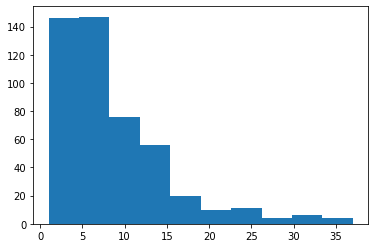

In [18]:
plt.hist(all_participants_optimal_K_list)

In [1]:
%store -r participant_to_metrics


In [2]:
participant_to_metrics[2]

{'overall_precision': 0.06218043216659979,
 'wedding_to_avg_precision': {34: 0.166584600014922,
  29: 0.050307960370231476,
  22: 0.04272560001811438,
  28: 0.067221759385286,
  17: 0.06042760230558682,
  38: -0.021294516153328665,
  6: 0.3034024724189559,
  1: -0.03688896636440124,
  19: 0.02283373363772715,
  20: -0.00415990898509306,
  2: 0.019756137031350728,
  23: 0.133987445220171},
 'ritual_to_avg_precision': {0: 0.1064219141436878,
  1: 0.010864453564634889,
  3: -0.027775222922329028,
  5: 0.06092251972179722,
  7: 0.05474257801858916,
  8: 0.06108173013325355,
  4: 0.0680315523291751,
  2: 0.0495556502085862,
  6: 0.11970867899598535},
 'wedding_to_ritual_to_avg_precision': {34: {0: 0.3894798766893152,
   1: -2.3084592067428355e-20,
   3: 0.09633688943399674,
   5: -3.062852966424291e-19,
   7: 0.27628033588685325,
   8: 0.005604163647633369},
  29: {0: 0.1966472153104404,
   1: -9.732740544029511e-19,
   3: -0.012040130274314206,
   4: -5.076450564378546e-19,
   7: 0.0417932

In [27]:
[x for x in data17[17].keys()]
#wedid = 38
# print(data17[17]["recall_wedding_to_event_topic_vectors"][wedid]['bounds'])
# print(len(data17[17]["recall_wedding_to_event_topic_vectors"][wedid]['bounds']) - 1, len(data17[17]["recall_wedding_to_event_topic_vectors"][wedid]['embeddings']))
#data17[17]["recall_wedding_to_event_to_sliding_windows"][wedid]
data17[17]['all_perceived_wedding_to_segment_to_event_to_sliding_windows'][38][2]

{0: [],
 1: ['the first ritual is the creation of',
  'the first ritual is the creation of and'],
 2: ['the first ritual is the creation of and gather'],
 3: ['the first ritual is the creation of and gather around',
  'the first ritual is the creation of and gather around the',
  'first ritual is the creation of and gather around the campfir',
  'ritual is the creation of and gather around the campfir dave',
  'is the creation of and gather around the campfir dave make',
  'the creation of and gather around the campfir dave make a',
  'creation of and gather around the campfir dave make a campfir',
  'of and gather around the campfir dave make a campfir and',
  'and gather around the campfir dave make a campfir and onc',
  'gather around the campfir dave make a campfir and onc it',
  'around the campfir dave make a campfir and onc it is'],
 4: ['the campfir dave make a campfir and onc it is go',
  'campfir dave make a campfir and onc it is go him',
  'dave make a campfir and onc it is 

[]

Stored 'participant_to_metrics' (dict)


In [11]:
%store -r participant_to_metrics
%store -r new_saved_dict
%store -r all_participants_optimal_K_list

--------
p_id:  34
28
22
1
17
29
19
23
38
6
2
34
20
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
> /Users/rosskempner/Desktop/Documents/Research/compmem/wedding_memory/code/python/topic_model_pipeline.py(953)get_participants_in_ritual_distinctiveness()
    951                 pdb.set_trace()
    952 
--> 953             correct_wedding_avg_precision = wedding_to_avg_precision_in_ritual[recall_wedding_id]
    954             mean_avg_precisions = sum(list(wedding_to_avg_precision_in_ritual.values())) / len(list(wedding_to_avg_precision_in_ritual.values()))
    955             stdev_avg_precisions = stdev(list(wedding_to_avg_precision_in_ritual.values()))

ipdb> c
hi
hi
hi
hi


Stored 'try2_participant_to_metrics' (dict)
Stored 'try2_new_saved_dict' (dict)
Stored 'try2_all_participants_optimal_K_list' (list)


39

--------
p_id:  28


/Users/rosskempner/opt/anaconda3/envs/mybrainiak/lib/python3.6/site-packages/sklearn/feature_extraction/text.py:386: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['magdalene'] not in stop_words.


23
19
1
29
2
34
20
6
28
22
17
38
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
> /Users/rosskempner/Desktop/Documents/Research/compmem/wedding_memory/code/python/topic_model_pipeline.py(953)get_participants_in_ritual_distinctiveness()
    951                 pdb.set_trace()
    952 
--> 953             correct_wedding_avg_precision = wedding_to_avg_precision_in_ritual[recall_wedding_id]
    954             mean_avg_precisions = sum(list(wedding_to_avg_precision_in_ritual.values())) / len(list(wedding_to_avg_precision_in_ritual.values()))
    955             stdev_avg_precisions = stdev(list(wedding_to_avg_precision_in_ritual.values()))

ipdb> c
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi


{28: {'overall_precision': 0.14409820716072036,
  'wedding_to_avg_precision': {23: 0.17238946399578817,
   19: 0.20744575425032763,
   1: 0.02570312125116051,
   29: 0.3124541977770567,
   2: 0.13837939220651926,
   34: 0.008320412209097837,
   20: 0.1471757582920736,
   6: 0.26594981079997243,
   28: 0.1893465499161084,
   22: 0.18951894255213336,
   17: 0.011969296361141933,
   38: 0.13044351845436603},
  'ritual_to_avg_precision': {0: 0.20458660315575886,
   1: 0.07899351257798597,
   3: 0.28643394519782006,
   5: 0.10351041462200326,
   7: 0.14378875630726817,
   8: 0.10543376920986723,
   2: 0.15601547365041085,
   4: 0.07638329857088696,
   6: 0.1816485126181175},
  'wedding_to_ritual_to_avg_precision': {23: {0: 0.34482153350251155,
    1: 0.21025145313632776,
    3: 0.1718170148927787,
    5: 0.1377196546725762,
    7: 0.20762656472713137,
    8: 0.05486004362822829},
   19: {0: 0.25411557709697336,
    1: 0.08954565484541473,
    2: 0.3261270223043494,
    4: 0.1796003394643982

In [6]:
def get_corr_between_two_windows(lda, vectorizer, w1, w2):
    w1 = " ".join([stemmer.stem(x) for x in w1.split()])
    w2 = " ".join([stemmer.stem(x) for x in w2.split()])

    # 1
    vectorized_window1 = vectorizer.transform([w1])
    topic_vector1 = lda.transform(vectorized_window1).flatten()
    # 2
    vectorized_window2 = vectorizer.transform([w2])
    topic_vector2 = lda.transform(vectorized_window2).flatten()
    # corr
    print(topic_vector1)
    print(topic_vector2)
    return pearsonr(topic_vector1, topic_vector2)
get_corr_between_two_windows(lda, vectorizer, w1 = "", w2 = "brazil")

[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.51 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.51 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]


(-0.020408163265306114, 0.8881289642599198)

In [9]:
p_id_list = [2,3,4,5,6,7,8,9,10,11,12,13, 14, 15, 17, 18, 19, 22, 23, 24, 25, 26,27, 28, 29, 30, 31, 32, 33, 34,35, 36,37,38 ,39,40 ,41 , 42, 43, 44]

len(p_id_list)

40

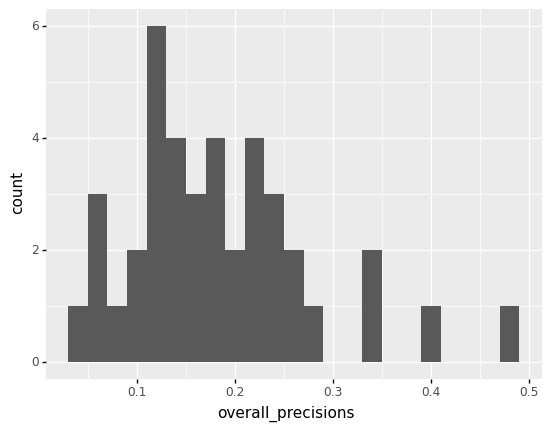

<ggplot: (-9223372029770057668)>

In [13]:
# plot overall precisions 
overall_precisions = [participant_to_metrics[pid]["overall_precision"] for pid in participant_to_metrics ]
overall_precisions
d = {"overall_precisions": overall_precisions}
df = pd.DataFrame(data = d)
(
    ggplot(df)
    + geom_histogram(aes(x="overall_precisions"), binwidth = 0.02)
    
)


(0.5053802095398009, 1.438328719814251e-186)


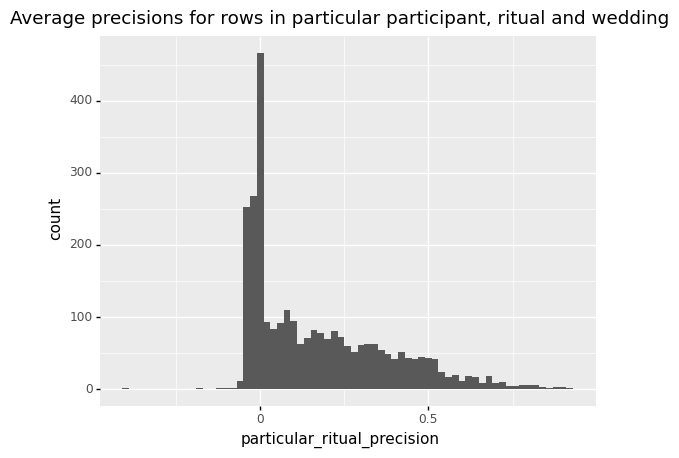

<ggplot: (-9223372029775128141)>

In [19]:
# individual ritual and wedding precisiions
overall_dvns_list = [] 
overall_prec_list = []
pid_list = []
rid_list = []
wprids_list = []
for pid in participant_to_metrics:
    for wedding_id in participant_to_metrics[pid]['recall_wedding_id_to_ritual_id_to_dvns']:
        for ritual_id in participant_to_metrics[pid]['recall_wedding_id_to_ritual_id_to_dvns'][wedding_id]:
            new_prec = participant_to_metrics[pid]['wedding_to_ritual_to_avg_precision'][wedding_id][ritual_id]
            new_dvns = participant_to_metrics[pid]['recall_wedding_id_to_ritual_id_to_dvns'][wedding_id][ritual_id]
            overall_dvns_list.append(new_dvns)
            overall_prec_list.append(new_prec)
            pid_list.append(pid)
            rid_list.append(ritual_id)
            wprids_list.append(str(pid) + "_"+ str(wedding_id) +  "_" +str(ritual_id))

print(pearsonr(overall_dvns_list,overall_prec_list))
d = {"particular_ritual_dvns": overall_dvns_list, "particular_ritual_precision": overall_prec_list, "pids": pid_list, "rids":rid_list,
        "pwrids":wprids_list}
df = pd.DataFrame(data = d)
(
    ggplot(df)
    + geom_histogram(aes(x="particular_ritual_precision"), binwidth = 0.02)
    + ggtitle("Average precisions for rows in particular participant, ritual and wedding")
    
)

(0.5053802095398009, 1.438328719814251e-186)


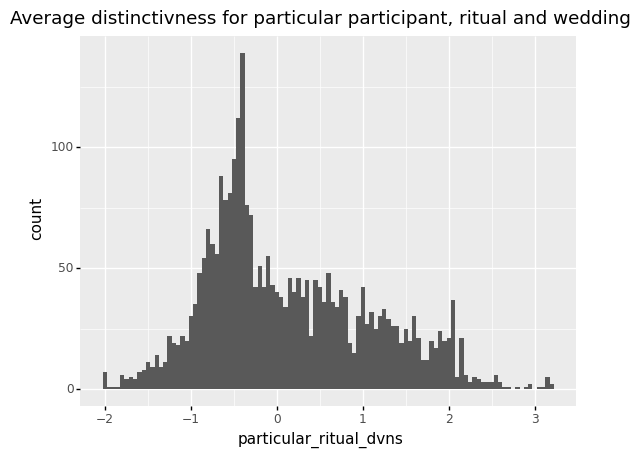

<ggplot: (-9223372029740480519)>

In [20]:
# individual ritual and wedding dvns
overall_dvns_list = [] 
overall_prec_list = []
pid_list = []
rid_list = []
wprids_list = []
for pid in participant_to_metrics:
    for wedding_id in participant_to_metrics[pid]['recall_wedding_id_to_ritual_id_to_dvns']:
        for ritual_id in participant_to_metrics[pid]['recall_wedding_id_to_ritual_id_to_dvns'][wedding_id]:
            new_prec = participant_to_metrics[pid]['wedding_to_ritual_to_avg_precision'][wedding_id][ritual_id]
            new_dvns = participant_to_metrics[pid]['recall_wedding_id_to_ritual_id_to_dvns'][wedding_id][ritual_id]
            overall_dvns_list.append(new_dvns)
            overall_prec_list.append(new_prec)
            pid_list.append(pid)
            rid_list.append(ritual_id)
            wprids_list.append(str(pid) + "_"+ str(wedding_id) +  "_" +str(ritual_id))

print(pearsonr(overall_dvns_list,overall_prec_list))
d = {"particular_ritual_dvns": overall_dvns_list, "particular_ritual_precision": overall_prec_list, "pids": pid_list, "rids":rid_list,
        "pwrids":wprids_list}
df = pd.DataFrame(data = d)
(
    ggplot(df)
   # ggplot(df[(df["particular_ritual_precision"] > 1e-13) | (df["particular_ritual_precision"] < -1*1e-13)])
   # ggplot(df[(df["particular_ritual_dvns"] < -0.3) & (df["particular_ritual_dvns"] > -0.6)])
    + geom_histogram(aes(x="particular_ritual_dvns"), binwidth = 0.05)
    + ggtitle("Average distinctivness for particular participant, ritual and wedding")
    
)

#new = df[(df["particular_ritual_dvns"] < -0.408) & (df["particular_ritual_dvns"] > -0.4083)]

#print(new["particular_ritual_dvns"], new["particular_ritual_precision"] )
#df[(df["particular_ritual_precision"] < 1e-18) & (df["particular_ritual_precision"] > -1*1e-18)]

(0.4479012369599292, 4.633386504258481e-25)


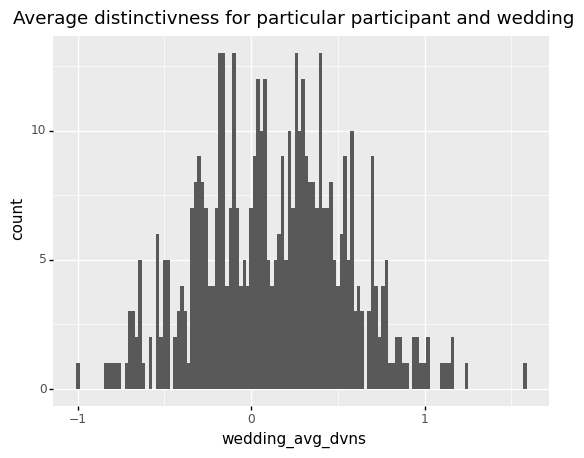

<ggplot: (-9223372029768127849)>

In [23]:
# WRD and precision at level of wedding avg for each participant
overall_dvns_list = [] 
overall_prec_list = []
pid_list = []
pwid_list = []
for pid in participant_to_metrics:
    for wedding_id in participant_to_metrics[pid]['wedding_to_avg_precision']:
        new_prec = participant_to_metrics[pid]['wedding_to_avg_precision'][wedding_id]
        new_dvns = participant_to_metrics[pid]['wedding_to_avg_dvns'][wedding_id]
        overall_dvns_list.append(new_dvns)
        overall_prec_list.append(new_prec)
        pid_list.append(pid)
        pwid_list.append(str(pid) + "_" + str(wedding_id))
print(pearsonr(overall_dvns_list,overall_prec_list))
d = {"wedding_avg_dvns": overall_dvns_list, "wedding_avg_precision": overall_prec_list, "pids": pid_list, "pwid_list": pwid_list}
df = pd.DataFrame(data = d)
(
    ggplot(df)
    + geom_histogram(aes(x="wedding_avg_dvns"), binwidth = 0.02)
    + ggtitle("Average distinctivness for particular participant and wedding")
    
)







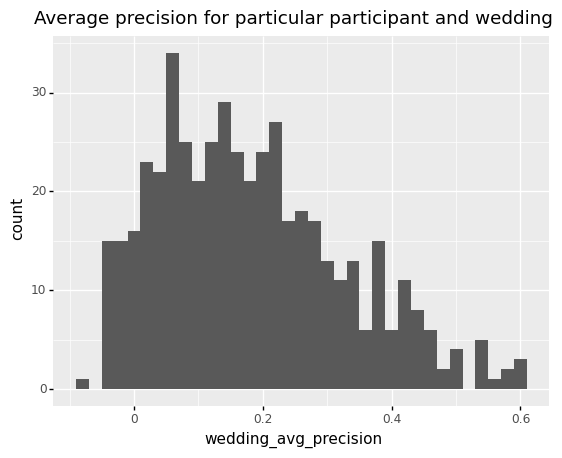

<ggplot: (-9223372029771615677)>

In [17]:
df = pd.DataFrame(data = d)
(
    ggplot(df)
    + geom_histogram(aes(x="wedding_avg_precision"), binwidth = 0.02)
    + ggtitle("Average precision for particular participant and wedding")
    
)

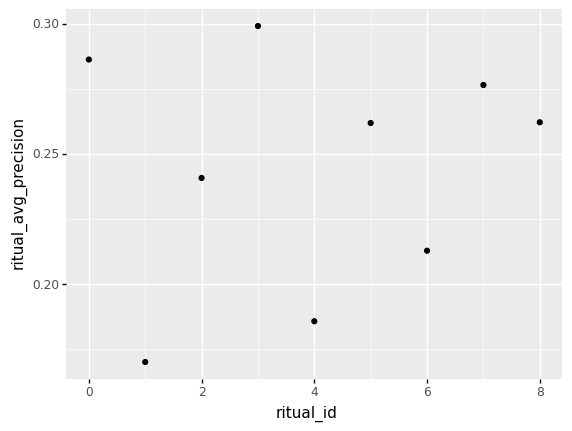

<ggplot: (7076215588)>

In [6]:
# plot by ritual precisions
ritual_precisions = []
ritual_id_list = []
ritual_to_precisions_list = {}
for pid in participant_to_metrics:
    for ritual_id in participant_to_metrics[pid]["ritual_to_avg_precision"]:
        precision = participant_to_metrics[pid]["ritual_to_avg_precision"][ritual_id]
        ritual_precisions.append(precision)
        ritual_id_list.append(ritual_id)
        if ritual_id not in ritual_to_precisions_list:
            ritual_to_precisions_list[ritual_id] = []
        ritual_to_precisions_list[ritual_id].append(precision)
# now get avg
ritual_avg_ids = []
ritual_avg_list = []
for ritual in ritual_to_precisions_list:
    ritual_avg_list.append(sum(ritual_to_precisions_list[ritual]) / len(ritual_to_precisions_list[ritual]))
    ritual_avg_ids.append(ritual)
d = {"ritual_avg_precision": ritual_avg_list, "ritual_id": ritual_avg_ids}
df = pd.DataFrame(data = d)
(ggplot(df) 
     + geom_point(aes(x="ritual_id", y="ritual_avg_precision"))
)

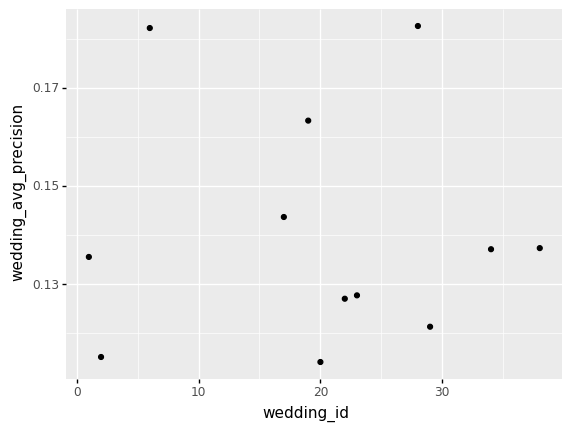

<ggplot: (-9223372029710316309)>

In [56]:
# plot by wedding precisions
wedding_precisions = []
wedding_id_list = []
pid_list = []
wedding_to_precisions_list = {}

for pid in participant_to_metrics:

    for wedding_id in participant_to_metrics[pid]["wedding_to_avg_precision"]:
        precision = participant_to_metrics[pid]["wedding_to_avg_precision"][wedding_id]
        wedding_precisions.append(precision)
        wedding_id_list.append(wedding_id)
        pid_list.append(pid)
        if wedding_id not in wedding_to_precisions_list:
            wedding_to_precisions_list[wedding_id] = []
        wedding_to_precisions_list[wedding_id].append(precision)

wedding_avg_ids = []
wedding_avg_list = []
for wedding in wedding_to_precisions_list:
    wedding_avg_list.append(sum(wedding_to_precisions_list[wedding]) / len(wedding_to_precisions_list[wedding]))
    wedding_avg_ids.append(wedding)
d = {"wedding_avg_precision": wedding_avg_list, "wedding_id": wedding_avg_ids}
df = pd.DataFrame(data = d)
(ggplot(df) 
     + geom_point(aes(x="wedding_id", y="wedding_avg_precision"))
)


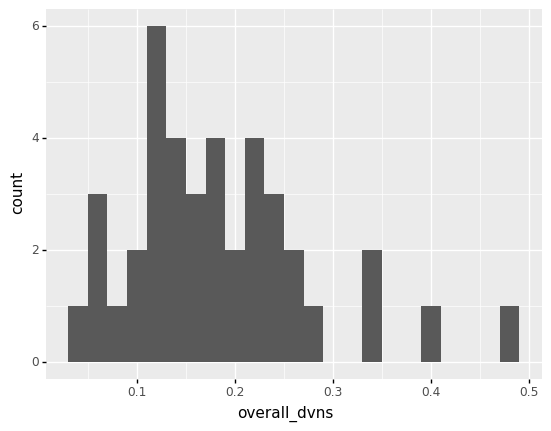

<ggplot: (7117728790)>

In [18]:
# plot overall dvns
overall_dvns = [participant_to_metrics[pid]["overall_dvns"] for pid in participant_to_metrics ]
overall_precisions
d = {"overall_dvns": overall_precisions}
df = pd.DataFrame(data = d)
(
    ggplot(df)
    + geom_histogram(aes(x="overall_dvns"), binwidth = 0.02) 
)

(0.4092908220607658, 0.00872903914644797)


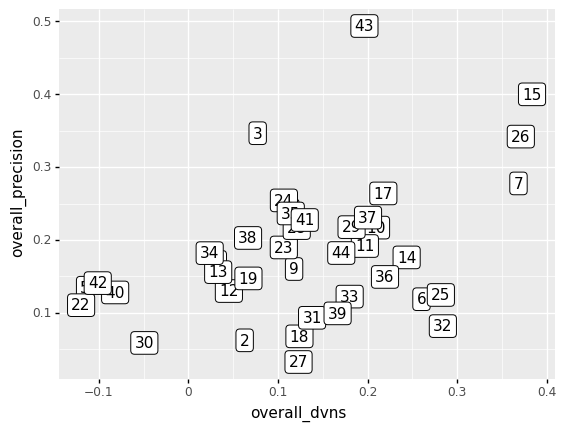

In [21]:
def plot_precision_on_dnvs_by_subject(participant_to_metrics):
    overall_dvns_list = [] 
    overall_prec_list = []
    pid_list = []
    for pid in participant_to_metrics:
        overall_dvns_list.append(participant_to_metrics[pid]["overall_dvns"])
        overall_prec_list.append(participant_to_metrics[pid]["overall_precision"])
        pid_list.append(pid)
    print(pearsonr(overall_dvns_list,overall_prec_list))
    d = {"overall_dvns": overall_dvns_list, "overall_precision": overall_prec_list, "pids": pid_list}
    df = pd.DataFrame(data = d)
    (ggplot(df) 
         + geom_point(aes(x="overall_dvns", y="overall_precision"))
       + geom_label(aes(x="overall_dvns", y="overall_precision",label="factor(pids)"))
    ).draw()
plot_precision_on_dnvs_by_subject(participant_to_metrics)

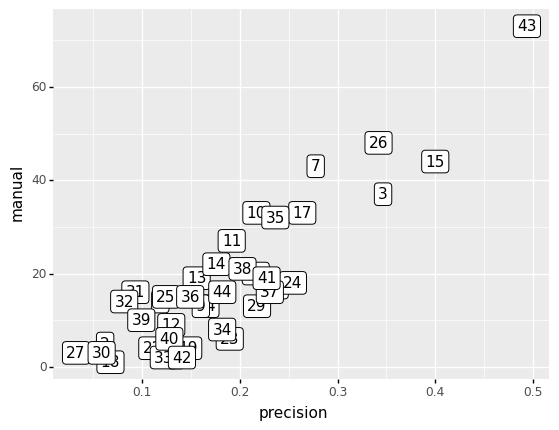

In [22]:
def plot_precision_vs_manual():
    data_input_dir = "../../data/"
    manual_performance_df =  pd.read_csv(data_input_dir + "manual_performance/wedding_recall_manual_performance.csv")
    participant_id_list = []
    automatic_measures_list = []
    manual_measures_list = []
    pid_list = []
    for participant_id in participant_to_metrics:
        pid_list.append(participant_id)
        # get the automatic metric
        auto_metric = participant_to_metrics[participant_id]["overall_precision"]
        automatic_measures_list.append(auto_metric)
        # get the manual metric for this participant
        query_colname = "s_" + str(participant_id)
        manual_metric = manual_performance_df[query_colname][0]
        manual_measures_list.append(manual_metric) 
    d = {"precision": automatic_measures_list, "manual": manual_measures_list, "pids": pid_list}
    df = pd.DataFrame(data = d)
    (ggplot(df) 
         + geom_point(aes(x="precision", y="manual"))
       + geom_label(aes(x="precision", y="manual",label="factor(pids)"))
    ).draw()
plot_precision_vs_manual()

SyntaxError: invalid syntax (<ipython-input-82-6f00a2bd750c>, line 6)

(0.5056945734187559, 7.776030739397388e-187)


,particular_ritual_dvns,particular_ritual_precision,pids,rids,pwrids
1664,0.167506,0.136298,28,2,28_19_2
1670,1.199402,0.222965,28,2,28_1_2
1676,1.549336,0.431418,28,2,28_29_2
1682,-0.298042,0.089874,28,2,28_2_2
1688,0.415612,0.054467,28,2,28_34_2
1706,0.023234,0.228624,28,2,28_28_2


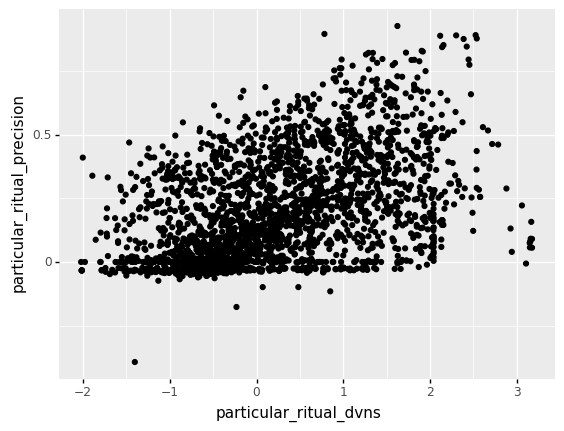

In [21]:
def plot_precision_on_dnvs_by_wedding_and_ritual(participant_to_metrics):
    overall_dvns_list = [] 
    overall_prec_list = []
    pid_list = []
    rid_list = []
    wprids_list = []
    for pid in participant_to_metrics:
        for wedding_id in participant_to_metrics[pid]['recall_wedding_id_to_ritual_id_to_dvns']:
            for ritual_id in participant_to_metrics[pid]['recall_wedding_id_to_ritual_id_to_dvns'][wedding_id]:
                new_prec = participant_to_metrics[pid]['wedding_to_ritual_to_avg_precision'][wedding_id][ritual_id]
                new_dvns = participant_to_metrics[pid]['recall_wedding_id_to_ritual_id_to_dvns'][wedding_id][ritual_id]
                overall_dvns_list.append(new_dvns)
                overall_prec_list.append(new_prec)
                pid_list.append(pid)
                rid_list.append(ritual_id)
                wprids_list.append(str(pid) + "_"+ str(wedding_id) +  "_" +str(ritual_id))
    
    print(pearsonr(overall_dvns_list,overall_prec_list))
    d = {"particular_ritual_dvns": overall_dvns_list, "particular_ritual_precision": overall_prec_list, "pids": pid_list, "rids":rid_list,
            "pwrids":wprids_list}
    df = pd.DataFrame(data = d)
    (ggplot(df) 
         + geom_point(aes(x="particular_ritual_dvns", y="particular_ritual_precision"))
     #  + geom_label(aes(x="particular_ritual_dvns", y="particular_ritual_precision",label="factor(pwrids)"), label_size=0.03)
    ).draw()
    return df 
    
df = plot_precision_on_dnvs_by_wedding_and_ritual(participant_to_metrics)
#df.loc[(df["particular_ritual_dvns"] > 1.73) & (df["particular_ritual_dvns"] < 1.75)]  
df.loc[(df["pids"] == 28) & (df["rids"] == 2)]  

(0.487199766775395, 2.863238732381131e-29)


,wedding_avg_dvns,wedding_avg_precision,pids,pwid_list
356,1.034899,0.034745,35,35_23


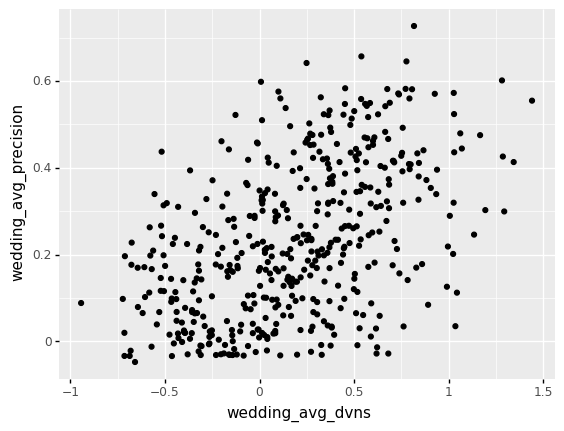

In [27]:
def plot_precision_on_dnvs_by_wedding_and_participant(participant_to_metrics):
    overall_dvns_list = [] 
    overall_prec_list = []
    pid_list = []
    pwid_list = []
    for pid in participant_to_metrics:
        for wedding_id in participant_to_metrics[pid]['wedding_to_avg_precision']:
            new_prec = participant_to_metrics[pid]['wedding_to_avg_precision'][wedding_id]
            new_dvns = participant_to_metrics[pid]['wedding_to_avg_dvns'][wedding_id]
            overall_dvns_list.append(new_dvns)
            overall_prec_list.append(new_prec)
            pid_list.append(pid)
            pwid_list.append(str(pid) + "_" + str(wedding_id))
    print(pearsonr(overall_dvns_list,overall_prec_list))
    d = {"wedding_avg_dvns": overall_dvns_list, "wedding_avg_precision": overall_prec_list, "pids": pid_list, "pwid_list": pwid_list}
    df = pd.DataFrame(data = d)
    (ggplot(df) 
         + geom_point(aes(x="wedding_avg_dvns", y="wedding_avg_precision"))
      # + geom_label(aes(x="wedding_avg_dvns", y="wedding_avg_precision",label="factor(pwid_list)"), label_size=0.03)
    ).draw()
    return df
df = plot_precision_on_dnvs_by_wedding_and_participant(participant_to_metrics)
df1 = df[(df["wedding_avg_dvns"] > 1)] 
df2 = df1[df1["wedding_avg_precision"] < 0.1]
df2

(0.487199766775395, 2.863238732381131e-29)


,wedding_avg_dvns,wedding_avg_precision,pids,pwid_list
356,1.034899,0.034745,35,35_23


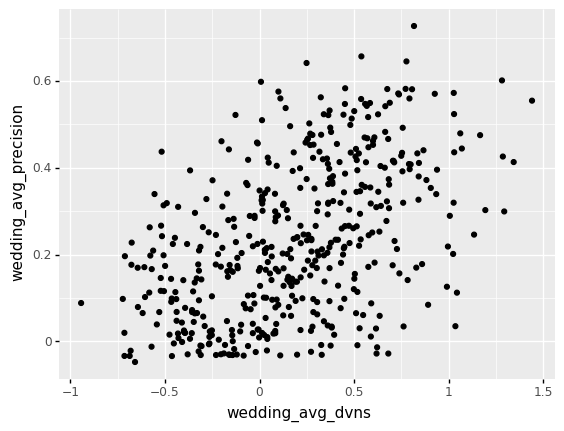

In [27]:
def plot_precision_on_dnvs_by_wedding_and_participant(participant_to_metrics):
    overall_dvns_list = [] 
    overall_prec_list = []
    pid_list = []
    pwid_list = []
    for pid in participant_to_metrics:
        for wedding_id in participant_to_metrics[pid]['wedding_to_avg_precision']:
            new_prec = participant_to_metrics[pid]['wedding_to_avg_precision'][wedding_id]
            new_dvns = participant_to_metrics[pid]['wedding_to_avg_dvns'][wedding_id]
            overall_dvns_list.append(new_dvns)
            overall_prec_list.append(new_prec)
            pid_list.append(pid)
            pwid_list.append(str(pid) + "_" + str(wedding_id))
    print(pearsonr(overall_dvns_list,overall_prec_list))
    d = {"wedding_avg_dvns": overall_dvns_list, "wedding_avg_precision": overall_prec_list, "pids": pid_list, "pwid_list": pwid_list}
    df = pd.DataFrame(data = d)
    (ggplot(df) 
         + geom_point(aes(x="wedding_avg_dvns", y="wedding_avg_precision"))
      # + geom_label(aes(x="wedding_avg_dvns", y="wedding_avg_precision",label="factor(pwid_list)"), label_size=0.03)
    ).draw()
    return df
df = plot_precision_on_dnvs_by_wedding_and_participant(participant_to_metrics)
df1 = df[(df["wedding_avg_dvns"] > 1)] 
df2 = df1[df1["wedding_avg_precision"] < 0.1]
df2

# Grid Search!

num_topics:  50 perceived_window_length:  3 recall_window_length:  3
got the lda model!
17 0
17 1
17 2
17 3
17 4
17 5
17 6
17 7
17 8
19 0
19 1
19 2
19 3
19 4
19 5
19 6
19 7
19 8
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
20 0
20 1
20 2
20 3
20 4
20 5
20 6
20 7
20 8
22 0
22 1
22 2
22 3
22 4
22 5
22 6
22 7
22 8
23 0
23 1
23 2
23 3
23 4
23 5
23 6
23 7
23 8
28 0
28 1
28 2
28 3
28 4
28 5
28 6
28 7
28 8
29 0
29 1
29 2
29 3
29 4
29 5
29 6
29 7
29 8
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
34 0
34 1
34 2
34 3
34 4
34 5
34 6
34 7
34 8
38 0
38 1
38 2
38 3
38 4
38 5
38 6
38 7
38 8
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
completed the perceived wedding segmentation
--------
p_id:  2
34 None
29 None
22 None
28 None
17 None
38 None
6 None
1 None
19 None
20 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  3
22 None
19 None
38 None
20 None
1 None
6 None
23 None
28 None
34 None
17 None
2 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  4
19 None
34 Non

22 None
28 None
29 None
6 None
17 None
20 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  5
20 None
38 None
28 None
19 None
2 None
23 None
34 None
1 None
17 None
22 None
29 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  6
34 None
23 None
6 None
20 None
17 None
22 None
1 None
19 None
38 None
28 None
29 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  7
1 None
34 None
20 None
22 None
38 None
23 None
29 None
28 None
6 None
2 None
19 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  8
1 None
20 None
29 None
38 None
6 None
2 None
28 None
23 None
17 None
34 None
19 None
22 None
got participants event seg
got precision
got dvns
--------
p_id:  9
6 None
17 None
20 None
22 None
19 None
34 None
1 None
23 None
29 None
28 None
38 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  10
38 None
22 None
2 None
29 None
34 None
20 None
17 None
23 None
19 None
6

got participants event seg
got precision
got dvns
--------
p_id:  11
29 None
17 None
19 None
1 None
6 None
34 None
22 None
20 None
28 None
38 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  12
23 None
19 None
17 None
22 None
6 None
1 None
20 None
34 None
38 None
29 None
2 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  13
22 None
28 None
34 None
38 None
23 None
20 None
1 None
2 None
29 None
17 None
6 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  14
23 None
29 None
34 None
2 None
20 None
1 None
19 None
17 None
28 None
6 None
22 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  15
20 None
38 None
34 None
23 None
19 None
1 None
28 None
22 None
6 None
29 None
2 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  17
34 None
38 None
23 None
6 None
19 None
2 None
17 None
22 None
1 None
29 None
28 None
20 None
got participants event seg
g

29 None
23 None
19 None
22 None
2 None
1 None
17 None
38 None
34 None
6 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  19
22 None
29 None
2 None
20 None
1 None
19 None
34 None
28 None
38 None
17 None
23 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  22
17 None
34 None
6 None
38 None
22 None
2 None
29 None
20 None
23 None
1 None
19 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  23
20 None
28 None
22 None
1 None
34 None
17 None
6 None
2 None
23 None
38 None
29 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  24
22 None
28 None
6 None
38 None
2 None
34 None
23 None
17 None
29 None
19 None
20 None
1 None
got participants event seg
got precision
got dvns
--------
p_id:  25
19 None
17 None
22 None
6 None
1 None
28 None
23 None
34 None
20 None
2 None
29 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  26
17 None
1 None
22 None
20 None
34 No

28 None
19 None
6 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  27
17 None
22 None
20 None
19 None
2 None
23 None
38 None
1 None
28 None
29 None
34 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  28
23 None
19 None
1 None
29 None
2 None
34 None
20 None
6 None
28 None
22 None
17 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  29
6 None
20 None
29 None
19 None
22 None
38 None
23 None
34 None
1 None
28 None
2 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  30
38 None
17 None
22 None
34 None
2 None
1 None
19 None
28 None
20 None
6 None
23 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  31
29 None
34 None
2 None
38 None
22 None
17 None
19 None
6 None
28 None
23 None
1 None
20 None
got participants event seg
got precision
got dvns
--------
p_id:  32
1 None
2 None
19 None
22 None
34 None
23 None
6 None
29 None
28 None
20 None
17 None
38 No

...

6 None
20 None
29 None
19 None
22 None
38 None
23 None
34 None
1 None
28 None
2 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  30
38 None
17 None
22 None
34 None
2 None
1 None
19 None
28 None
20 None
6 None
23 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  31
29 None
34 None
2 None
38 None
22 None
17 None
19 None
6 None
28 None
23 None
1 None
20 None
got participants event seg
got precision
got dvns
--------
p_id:  32
1 None
2 None
19 None
22 None
34 None
23 None
6 None
29 None
28 None
20 None
17 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  33
22 None
19 None
1 None
20 None
2 None
28 None
6 None
17 None
29 None
34 None
38 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  34
28 None
22 None
1 None
17 None
29 None
19 None
23 None
38 None
6 None
2 None
34 None
20 None
got participants event seg
got precision
got dvns
--------
p_id:  35
17 None
1 None
19 None
28 No

38 None
23 None
6 None
22 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  36
22 None
23 None
1 None
17 None
38 None
28 None
29 None
19 None
20 None
6 None
34 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  37
22 None
29 None
34 None
28 None
2 None
23 None
17 None
6 None
1 None
19 None
20 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  38
6 None
2 None
29 None
1 None
34 None
17 None
28 None
38 None
23 None
20 None
22 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  39
22 None
1 None
29 None
20 None
17 None
19 None
28 None
23 None
6 None
38 None
34 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  40
23 None
22 None
29 None
1 None
19 None
34 None
6 None
20 None
28 None
38 None
17 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  41
20 None
19 None
17 None
34 None
6 None
28 None
38 None
1 None
2 None
22 None
23 No

29 None
19 None
17 None
38 None
20 None
6 None
22 None
2 None
23 None
1 None
34 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  43
17 None
38 None
22 None
28 None
2 None
19 None
20 None
1 None
6 None
34 None
29 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  44
2 None
22 None
38 None
17 None
23 None
19 None
29 None
6 None
20 None
34 None
28 None
1 None
got participants event seg
got precision
got dvns
completed the recall wedding segmentation and metrics
num_topics:  350 perceived_window_length:  15 recall_window_length:  3
got the lda model!
17 0
17 1
17 2
17 3
17 4
17 5
17 6
17 7
17 8
19 0
19 1
19 2
19 3
19 4
19 5
19 6
19 7
19 8
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
20 0
20 1
20 2
20 3
20 4
20 5
20 6
20 7
20 8
22 0
22 1
22 2
22 3
22 4
22 5
22 6
22 7
22 8
23 0
23 1
23 2
23 3
23 4
23 5
23 6
23 7
23 8
28 0
28 1
28 2
28 3
28 4
28 5
28 6
28 7
28 8
29 0
29 1
29 2
29 3
29 4
29 5
29 6
29 7
29 8
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
34

34 6
34 7
34 8
38 0
38 1
38 2
38 3
38 4
38 5
38 6
38 7
38 8
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
completed the perceived wedding segmentation
--------
p_id:  2
34 None
29 None
22 None
28 None
17 None
38 None
6 None
1 None
19 None
20 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  3
22 None
19 None
38 None
20 None
1 None
6 None
23 None
28 None
34 None
17 None
2 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  4
19 None
34 None
1 None
23 None
38 None
22 None
28 None
29 None
6 None
17 None
20 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  5
20 None
38 None
28 None
19 None
2 None
23 None
34 None
1 None
17 None
22 None
29 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  6
34 None
23 None
6 None
20 None
17 None
22 None
1 None
19 None
38 None
28 None
29 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  7
1 None
34 None
20 None
22 None
38 No

28 None
6 None
2 None
19 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  8
1 None
20 None
29 None
38 None
6 None
2 None
28 None
23 None
17 None
34 None
19 None
22 None
got participants event seg
got precision
got dvns
--------
p_id:  9
6 None
17 None
20 None
22 None
19 None
34 None
1 None
23 None
29 None
28 None
38 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  10
38 None
22 None
2 None
29 None
34 None
20 None
17 None
23 None
19 None
6 None
1 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  11
29 None
17 None
19 None
1 None
6 None
34 None
22 None
20 None
28 None
38 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  12
23 None
19 None
17 None
22 None
6 None
1 None
20 None
34 None
38 None
29 None
2 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  13
22 None
28 None
34 None
38 None
23 None
20 None
1 None
2 None
29 None
17 None
6 None


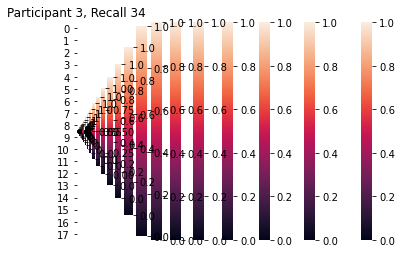

In [16]:
official_grid1 = grid_search_by_wedding_and_participant(num_topics_list = [50,100,150,200,250,300,350], perceived_window_length_list = [3,7,11,15,19,23], 
                recall_window_length_list = [3])

In [30]:
# first strip of the data to store all
cleaned_official_grid1 = []
for this_grid_corr, grid_parameters, other_data  in official_grid1:
    cleaned_official_grid1.append((this_grid_corr, grid_parameters))
%store cleaned_official_grid1
# then save the best 5 or so with the data
best5_official_grid1 = official_grid1[len(official_grid1) - 2:len(official_grid1)  ]
%store best5_official_grid1

Stored 'cleaned_official_grid1' (list)


KeyboardInterrupt: 

num_topics:  50 perceived_window_length:  3 recall_window_length:  7
got the lda model!
17 0
17 1
17 2
17 3
17 4
17 5
17 6
17 7
17 8
19 0
19 1
19 2
19 3
19 4
19 5
19 6
19 7
19 8
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
20 0
20 1
20 2
20 3
20 4
20 5
20 6
20 7
20 8
22 0
22 1
22 2
22 3
22 4
22 5
22 6
22 7
22 8
23 0
23 1
23 2
23 3
23 4
23 5
23 6
23 7
23 8
28 0
28 1
28 2
28 3
28 4
28 5
28 6
28 7
28 8
29 0
29 1
29 2
29 3
29 4
29 5
29 6
29 7
29 8
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
34 0
34 1
34 2
34 3
34 4
34 5
34 6
34 7
34 8
38 0
38 1
38 2
38 3
38 4
38 5
38 6
38 7
38 8
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
completed the perceived wedding segmentation
--------
p_id:  2
34 None
29 None
22 None
28 None
17 None
38 None
6 None
1 None
19 None
20 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  3
22 None
19 None
38 None
20 None
1 None
6 None
23 None
28 None
34 None
17 None
2 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  4
19 None
34 Non

22 None
28 None
29 None
6 None
17 None
20 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  5
20 None
38 None
28 None
19 None
2 None
23 None
34 None
1 None
17 None
22 None
29 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  6
34 None
23 None
6 None
20 None
17 None
22 None
1 None
19 None
38 None
28 None
29 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  7
1 None
34 None
20 None
22 None
38 None
23 None
29 None
28 None
6 None
2 None
19 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  8
1 None
20 None
29 None
38 None
6 None
2 None
28 None
23 None
17 None
34 None
19 None
22 None
got participants event seg
got precision
got dvns
--------
p_id:  9
6 None
17 None
20 None
22 None
19 None
34 None
1 None
23 None
29 None
28 None
38 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  10
38 None
22 None
2 None
29 None
34 None
20 None
17 None
23 None
19 None
6

got participants event seg
got precision
got dvns
--------
p_id:  11
29 None
17 None
19 None
1 None
6 None
34 None
22 None
20 None
28 None
38 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  12
23 None
19 None
17 None
22 None
6 None
1 None
20 None
34 None
38 None
29 None
2 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  13
22 None
28 None
34 None
38 None
23 None
20 None
1 None
2 None
29 None
17 None
6 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  14
23 None
29 None
34 None
2 None
20 None
1 None
19 None
17 None
28 None
6 None
22 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  15
20 None
38 None
34 None
23 None
19 None
1 None
28 None
22 None
6 None
29 None
2 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  17
34 None
38 None
23 None
6 None
19 None
2 None
17 None
22 None
1 None
29 None
28 None
20 None
got participants event seg
g

29 None
23 None
19 None
22 None
2 None
1 None
17 None
38 None
34 None
6 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  19
22 None
29 None
2 None
20 None
1 None
19 None
34 None
28 None
38 None
17 None
23 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  22
17 None
34 None
6 None
38 None
22 None
2 None
29 None
20 None
23 None
1 None
19 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  23
20 None
28 None
22 None
1 None
34 None
17 None
6 None
2 None
23 None
38 None
29 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  24
22 None
28 None
6 None
38 None
2 None
34 None
23 None
17 None
29 None
19 None
20 None
1 None
got participants event seg
got precision
got dvns
--------
p_id:  25
19 None
17 None
22 None
6 None
1 None
28 None
23 None
34 None
20 None
2 None
29 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  26
17 None
1 None
22 None
20 None
34 No

28 None
19 None
6 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  27
17 None
22 None
20 None
19 None
2 None
23 None
38 None
1 None
28 None
29 None
34 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  28
23 None
19 None
1 None
29 None
2 None
34 None
20 None
6 None
28 None
22 None
17 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  29
6 None
20 None
29 None
19 None
22 None
38 None
23 None
34 None
1 None
28 None
2 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  30
38 None
17 None
22 None
34 None
2 None
1 None
19 None
28 None
20 None
6 None
23 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  31
29 None
34 None
2 None
38 None
22 None
17 None
19 None
6 None
28 None
23 None
1 None
20 None
got participants event seg
got precision
got dvns
--------
p_id:  32
1 None
2 None
19 None
22 None
34 None
23 None
6 None
29 None
28 None
20 None
17 None
38 No

...

38 None
17 None
22 None
34 None
2 None
1 None
19 None
28 None
20 None
6 None
23 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  31
29 None
34 None
2 None
38 None
22 None
17 None
19 None
6 None
28 None
23 None
1 None
20 None
got participants event seg
got precision
got dvns
--------
p_id:  32
1 None
2 None
19 None
22 None
34 None
23 None
6 None
29 None
28 None
20 None
17 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  33
22 None
19 None
1 None
20 None
2 None
28 None
6 None
17 None
29 None
34 None
38 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  34
28 None
22 None
1 None
17 None
29 None
19 None
23 None
38 None
6 None
2 None
34 None
20 None
got participants event seg
got precision
got dvns
--------
p_id:  35
17 None
1 None
19 None
28 None
34 None
2 None
20 None
38 None
23 None
6 None
22 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  36
22 None
23 None
1 None
17 No

19 None
20 None
6 None
34 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  37
22 None
29 None
34 None
28 None
2 None
23 None
17 None
6 None
1 None
19 None
20 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  38
6 None
2 None
29 None
1 None
34 None
17 None
28 None
38 None
23 None
20 None
22 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  39
22 None
1 None
29 None
20 None
17 None
19 None
28 None
23 None
6 None
38 None
34 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  40
23 None
22 None
29 None
1 None
19 None
34 None
6 None
20 None
28 None
38 None
17 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  41
20 None
19 None
17 None
34 None
6 None
28 None
38 None
1 None
2 None
22 None
23 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  42
29 None
19 None
17 None
38 None
20 None
6 None
22 None
2 None
23 None
1 None
34 Non

17 None
38 None
22 None
28 None
2 None
19 None
20 None
1 None
6 None
34 None
29 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  44
2 None
22 None
38 None
17 None
23 None
19 None
29 None
6 None
20 None
34 None
28 None
1 None
got participants event seg
got precision
got dvns
completed the recall wedding segmentation and metrics
num_topics:  350 perceived_window_length:  15 recall_window_length:  7
got the lda model!
17 0
17 1
17 2
17 3
17 4
17 5
17 6
17 7
17 8
19 0
19 1
19 2
19 3
19 4
19 5
19 6
19 7
19 8
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
20 0
20 1
20 2
20 3
20 4
20 5
20 6
20 7
20 8
22 0
22 1
22 2
22 3
22 4
22 5
22 6
22 7
22 8
23 0
23 1
23 2
23 3
23 4
23 5
23 6
23 7
23 8
28 0
28 1
28 2
28 3
28 4
28 5
28 6
28 7
28 8
29 0
29 1
29 2
29 3
29 4
29 5
29 6
29 7
29 8
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
34 0
34 1
34 2
34 3
34 4
34 5
34 6
34 7
34 8
38 0
38 1
38 2
38 3
38 4
38 5
38 6
38 7
38 8
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
completed the perceived wedding segmen

34 None
29 None
22 None
28 None
17 None
38 None
6 None
1 None
19 None
20 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  3
22 None
19 None
38 None
20 None
1 None
6 None
23 None
28 None
34 None
17 None
2 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  4
19 None
34 None
1 None
23 None
38 None
22 None
28 None
29 None
6 None
17 None
20 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  5
20 None
38 None
28 None
19 None
2 None
23 None
34 None
1 None
17 None
22 None
29 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  6
34 None
23 None
6 None
20 None
17 None
22 None
1 None
19 None
38 None
28 None
29 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  7
1 None
34 None
20 None
22 None
38 None
23 None
29 None
28 None
6 None
2 None
19 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  8
1 None
20 None
29 None
38 None
6 N

23 None
17 None
34 None
19 None
22 None
got participants event seg
got precision
got dvns
--------
p_id:  9
6 None
17 None
20 None
22 None
19 None
34 None
1 None
23 None
29 None
28 None
38 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  10
38 None
22 None
2 None
29 None
34 None
20 None
17 None
23 None
19 None
6 None
1 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  11
29 None
17 None
19 None
1 None
6 None
34 None
22 None
20 None
28 None
38 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  12
23 None
19 None
17 None
22 None
6 None
1 None
20 None
34 None
38 None
29 None
2 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  13
22 None
28 None
34 None
38 None
23 None
20 None
1 None
2 None
29 None
17 None
6 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  14
23 None
29 None
34 None
2 None
20 None
1 None
19 None
17 None
28 None
6 None
22 No

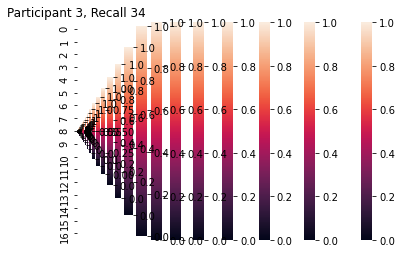

In [31]:
official_grid2 = grid_search_by_wedding_and_participant(num_topics_list = [50,100,150,200,250,300,350], perceived_window_length_list = [3,7,11,15,19,23], 
                recall_window_length_list = [7])

In [37]:
# first strip of the data to store all
cleaned_official_grid2 = []
for this_grid_corr, grid_parameters, other_data  in official_grid2:
    cleaned_official_grid2.append((this_grid_corr, grid_parameters))
%store cleaned_official_grid2


Stored 'cleaned_official_grid2' (list)


(array([31., 27.,  0., 26.,  0., 12.,  7.,  0.,  2.,  3.]),
 array([2. , 2.6, 3.2, 3.8, 4.4, 5. , 5.6, 6.2, 6.8, 7.4, 8. ]),
 <BarContainer object of 10 artists>)

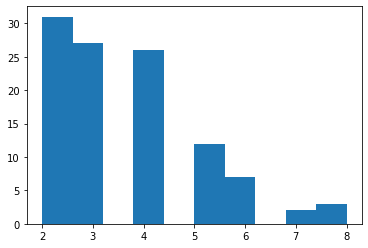

In [64]:
plt.hist(official_grid2[-1][2]["all_perceived_optimal_K_list"])

In [35]:
# %store -r first_grid_search
# %store -r sorted_correlations_list
# %store -r sorted_correlations_list2
# %store -r sorted_correlations_list3
#%store -r sorted_correlations_list4

num_topics:  50 perceived_window_length:  3 recall_window_length:  11
got the lda model!
17 0
17 1
17 2
17 3
17 4
17 5
17 6
17 7
17 8
19 0
19 1
19 2
19 3
19 4
19 5
19 6
19 7
19 8
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
20 0
20 1
20 2
20 3
20 4
20 5
20 6
20 7
20 8
22 0
22 1
22 2
22 3
22 4
22 5
22 6
22 7
22 8
23 0
23 1
23 2
23 3
23 4
23 5
23 6
23 7
23 8
28 0
28 1
28 2
28 3
28 4
28 5
28 6
28 7
28 8
29 0
29 1
29 2
29 3
29 4
29 5
29 6
29 7
29 8
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
34 0
34 1
34 2
34 3
34 4
34 5
34 6
34 7
34 8
38 0
38 1
38 2
38 3
38 4
38 5
38 6
38 7
38 8
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
completed the perceived wedding segmentation
--------
p_id:  2
34 None
29 None
22 None
28 None
17 None
38 None
6 None
1 None
19 None
20 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  3
22 None
19 None
38 None
20 None
1 None
6 None
23 None
28 None
34 None
17 None
2 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  4
19 None
34 No

22 None
28 None
29 None
6 None
17 None
20 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  5
20 None
38 None
28 None
19 None
2 None
23 None
34 None
1 None
17 None
22 None
29 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  6
34 None
23 None
6 None
20 None
17 None
22 None
1 None
19 None
38 None
28 None
29 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  7
1 None
34 None
20 None
22 None
38 None
23 None
29 None
28 None
6 None
2 None
19 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  8
1 None
20 None
29 None
38 None
6 None
2 None
28 None
23 None
17 None
34 None
19 None
22 None
got participants event seg
got precision
got dvns
--------
p_id:  9
6 None
17 None
20 None
22 None
19 None
34 None
1 None
23 None
29 None
28 None
38 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  10
38 None
22 None
2 None
29 None
34 None
20 None
17 None
23 None
19 None
6

got participants event seg
got precision
got dvns
--------
p_id:  11
29 None
17 None
19 None
1 None
6 None
34 None
22 None
20 None
28 None
38 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  12
23 None
19 None
17 None
22 None
6 None
1 None
20 None
34 None
38 None
29 None
2 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  13
22 None
28 None
34 None
38 None
23 None
20 None
1 None
2 None
29 None
17 None
6 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  14
23 None
29 None
34 None
2 None
20 None
1 None
19 None
17 None
28 None
6 None
22 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  15
20 None
38 None
34 None
23 None
19 None
1 None
28 None
22 None
6 None
29 None
2 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  17
34 None
38 None
23 None
6 None
19 None
2 None
17 None
22 None
1 None
29 None
28 None
20 None
got participants event seg
g

29 None
23 None
19 None
22 None
2 None
1 None
17 None
38 None
34 None
6 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  19
22 None
29 None
2 None
20 None
1 None
19 None
34 None
28 None
38 None
17 None
23 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  22
17 None
34 None
6 None
38 None
22 None
2 None
29 None
20 None
23 None
1 None
19 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  23
20 None
28 None
22 None
1 None
34 None
17 None
6 None
2 None
23 None
38 None
29 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  24
22 None
28 None
6 None
38 None
2 None
34 None
23 None
17 None
29 None
19 None
20 None
1 None
got participants event seg
got precision
got dvns
--------
p_id:  25
19 None
17 None
22 None
6 None
1 None
28 None
23 None
34 None
20 None
2 None
29 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  26
17 None
1 None
22 None
20 None
34 No

28 None
19 None
6 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  27
17 None
22 None
20 None
19 None
2 None
23 None
38 None
1 None
28 None
29 None
34 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  28
23 None
19 None
1 None
29 None
2 None
34 None
20 None
6 None
28 None
22 None
17 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  29
6 None
20 None
29 None
19 None
22 None
38 None
23 None
34 None
1 None
28 None
2 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  30
38 None
17 None
22 None
34 None
2 None
1 None
19 None
28 None
20 None
6 None
23 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  31
29 None
34 None
2 None
38 None
22 None
17 None
19 None
6 None
28 None
23 None
1 None
20 None
got participants event seg
got precision
got dvns
--------
p_id:  32
1 None
2 None
19 None
22 None
34 None
23 None
6 None
29 None
28 None
20 None
17 None
38 No

...

23 None
34 None
1 None
28 None
2 None
17 None
got participants event seg
got precision
got dvns
--------
p_id:  30
38 None
17 None
22 None
34 None
2 None
1 None
19 None
28 None
20 None
6 None
23 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  31
29 None
34 None
2 None
38 None
22 None
17 None
19 None
6 None
28 None
23 None
1 None
20 None
got participants event seg
got precision
got dvns
--------
p_id:  32
1 None
2 None
19 None
22 None
34 None
23 None
6 None
29 None
28 None
20 None
17 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  33
22 None
19 None
1 None
20 None
2 None
28 None
6 None
17 None
29 None
34 None
38 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  34
28 None
22 None
1 None
17 None
29 None
19 None
23 None
38 None
6 None
2 None
34 None
20 None
got participants event seg
got precision
got dvns
--------
p_id:  35
17 None
1 None
19 None
28 None
34 None
2 None
20 None
38 None
23 None
6 Non

22 None
23 None
1 None
17 None
38 None
28 None
29 None
19 None
20 None
6 None
34 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  37
22 None
29 None
34 None
28 None
2 None
23 None
17 None
6 None
1 None
19 None
20 None
38 None
got participants event seg
got precision
got dvns
--------
p_id:  38
6 None
2 None
29 None
1 None
34 None
17 None
28 None
38 None
23 None
20 None
22 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  39
22 None
1 None
29 None
20 None
17 None
19 None
28 None
23 None
6 None
38 None
34 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  40
23 None
22 None
29 None
1 None
19 None
34 None
6 None
20 None
28 None
38 None
17 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  41
20 None
19 None
17 None
34 None
6 None
28 None
38 None
1 None
2 None
22 None
23 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  42
29 None
19 None
17 None
38 N

22 None
2 None
23 None
1 None
34 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  43
17 None
38 None
22 None
28 None
2 None
19 None
20 None
1 None
6 None
34 None
29 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  44
2 None
22 None
38 None
17 None
23 None
19 None
29 None
6 None
20 None
34 None
28 None
1 None
got participants event seg
got precision
got dvns
completed the recall wedding segmentation and metrics
num_topics:  350 perceived_window_length:  15 recall_window_length:  11
got the lda model!
17 0
17 1
17 2
17 3
17 4
17 5
17 6
17 7
17 8
19 0
19 1
19 2
19 3
19 4
19 5
19 6
19 7
19 8
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
20 0
20 1
20 2
20 3
20 4
20 5
20 6
20 7
20 8
22 0
22 1
22 2
22 3
22 4
22 5
22 6
22 7
22 8
23 0
23 1
23 2
23 3
23 4
23 5
23 6
23 7
23 8
28 0
28 1
28 2
28 3
28 4
28 5
28 6
28 7
28 8
29 0
29 1
29 2
29 3
29 4
29 5
29 6
29 7
29 8
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
34 0
34 1
34 2
34 3
34 4
34 5
34 6
34 7
34 8
38 

38 6
38 7
38 8
6 0
6 1
6 2
6 3
6 4
6 5
6 6
6 7
6 8
completed the perceived wedding segmentation
--------
p_id:  2
34 None
29 None
22 None
28 None
17 None
38 None
6 None
1 None
19 None
20 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  3
22 None
19 None
38 None
20 None
1 None
6 None
23 None
28 None
34 None
17 None
2 None
29 None
got participants event seg
got precision
got dvns
--------
p_id:  4
19 None
34 None
1 None
23 None
38 None
22 None
28 None
29 None
6 None
17 None
20 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  5
20 None
38 None
28 None
19 None
2 None
23 None
34 None
1 None
17 None
22 None
29 None
6 None
got participants event seg
got precision
got dvns
--------
p_id:  6
34 None
23 None
6 None
20 None
17 None
22 None
1 None
19 None
38 None
28 None
29 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  7
1 None
34 None
20 None
22 None
38 None
23 None
29 None
28 None
6 None
2 None
19 N

1 None
20 None
29 None
38 None
6 None
2 None
28 None
23 None
17 None
34 None
19 None
22 None
got participants event seg
got precision
got dvns
--------
p_id:  9
6 None
17 None
20 None
22 None
19 None
34 None
1 None
23 None
29 None
28 None
38 None
2 None
got participants event seg
got precision
got dvns
--------
p_id:  10
38 None
22 None
2 None
29 None
34 None
20 None
17 None
23 None
19 None
6 None
1 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  11
29 None
17 None
19 None
1 None
6 None
34 None
22 None
20 None
28 None
38 None
2 None
23 None
got participants event seg
got precision
got dvns
--------
p_id:  12
23 None
19 None
17 None
22 None
6 None
1 None
20 None
34 None
38 None
29 None
2 None
28 None
got participants event seg
got precision
got dvns
--------
p_id:  13
22 None
28 None
34 None
38 None
23 None
20 None
1 None
2 None
29 None
17 None
6 None
19 None
got participants event seg
got precision
got dvns
--------
p_id:  14
23 None
29 None
34 None
2 Non

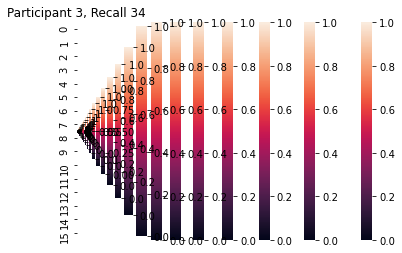

In [4]:
official_grid3 = grid_search_by_wedding_and_participant(num_topics_list = [50,100,150,200,250,300,350], perceived_window_length_list = [3,7,11,15,19,23], 
                recall_window_length_list = [11])

In [10]:
%store -r cleaned_official_grid1

In [5]:
# first strip of the data to store all
cleaned_official_grid3 = []
for this_grid_corr, grid_parameters, other_data  in official_grid3:
    cleaned_official_grid3.append((this_grid_corr, grid_parameters))
%store cleaned_official_grid3


Stored 'cleaned_official_grid3' (list)


In [12]:
[x for x in cleaned_official_grid3]

[(0.5724026500442674,
  {'num_topics': 50,
   'perceived_window_length': 3,
   'recall_window_length': 11}),
 (0.672324588156125,
  {'num_topics': 50,
   'perceived_window_length': 23,
   'recall_window_length': 11}),
 (0.6938337392706692,
  {'num_topics': 50,
   'perceived_window_length': 19,
   'recall_window_length': 11}),
 (0.6982135644403286,
  {'num_topics': 50,
   'perceived_window_length': 7,
   'recall_window_length': 11}),
 (0.7255608681239066,
  {'num_topics': 100,
   'perceived_window_length': 19,
   'recall_window_length': 11}),
 (0.7422049365443687,
  {'num_topics': 50,
   'perceived_window_length': 15,
   'recall_window_length': 11}),
 (0.7432267742502455,
  {'num_topics': 100,
   'perceived_window_length': 23,
   'recall_window_length': 11}),
 (0.7433317163298693,
  {'num_topics': 200,
   'perceived_window_length': 19,
   'recall_window_length': 11}),
 (0.7505736786512943,
  {'num_topics': 300,
   'perceived_window_length': 23,
   'recall_window_length': 11}),
 (0.75339

(0.8494275573334154, 8.622201837550006e-135)
(0.8563551298371298, 2.6999117788773786e-139)


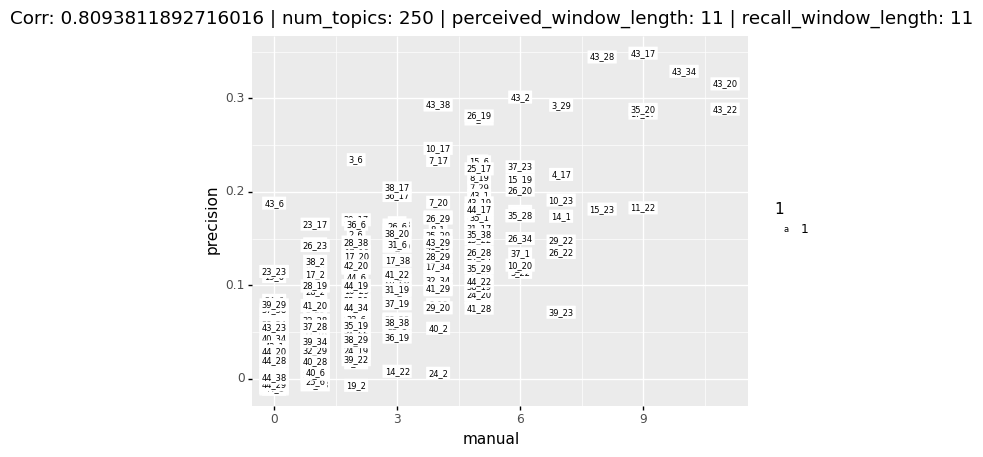

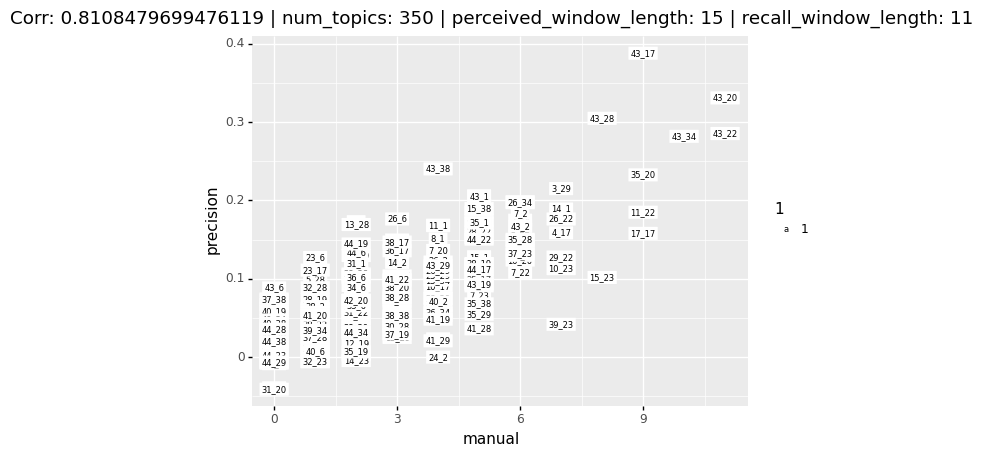

In [8]:
for this_grid_corr, grid_parameters, other_data  in official_grid3[len(official_grid3) - 2:len(official_grid3)  ]:
    
    d = {"precision": other_data["automatic_measures_list"], "manual": other_data["manual_measures_list"], "pwids": other_data["p_and_w_id_list"]}
    df = pd.DataFrame(data = d)
    (ggplot(df) 
         + geom_point(aes(x="manual", y="precision"))
        # + ylim(-0.25,0.55)
        + ggtitle("Corr: " + str(this_grid_corr) + " | num_topics: " + str(grid_parameters["num_topics"]) + " | perceived_window_length: " + str(grid_parameters["perceived_window_length"]) + " | recall_window_length: " + str(grid_parameters["recall_window_length"]))
        + geom_label(aes(x="manual", y="precision", label="factor(pwids)", size = 1), label_size = 0.001, label_r=0.001)
    ).draw()
    
    print(pearsonr(d["precision"], d["manual"]))




(array([147., 143.,  87.,  43.,  23.,  13.,   8.,   5.,   8.,   3.]),
 array([ 1. ,  4.7,  8.4, 12.1, 15.8, 19.5, 23.2, 26.9, 30.6, 34.3, 38. ]),
 <BarContainer object of 10 artists>)

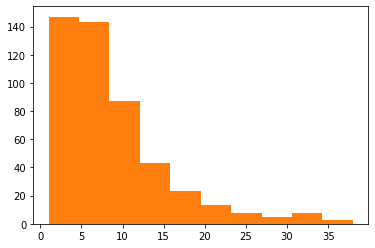

In [4]:
plt.hist(all_perceived_optimal_K_list)
plt.hist(all_recall_participants_optimal_K_list)

# Some Other Event Segmentation HMM


In [23]:
hmm_sim = brainiak.eventseg.event.EventSegment(5)
hmm_sim.fit(window_by_embedding_matrix)

NameError: name 'window_by_embedding_matrix' is not defined

Text(0.5, 0, 'Topics')

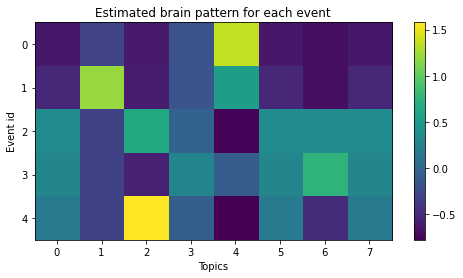

In [16]:
f, ax = plt.subplots(1,1, figsize=(8, 4))
img = ax.imshow(hmm_sim.event_pat_.T, cmap='viridis', aspect='auto')
f.colorbar(img)
ax.set_title('Estimated brain pattern for each event')
ax.set_ylabel('Event id')
ax.set_xlabel('Topics')

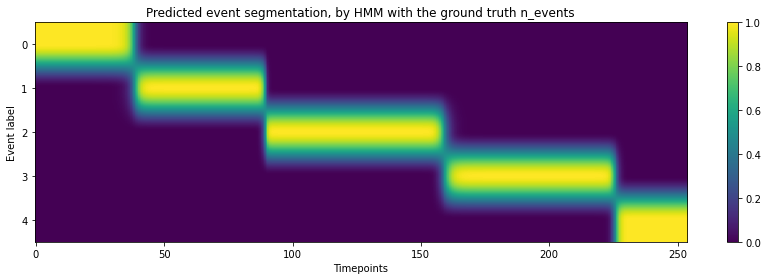

In [17]:
# plot 
f, ax = plt.subplots(1,1, figsize=(12,4))

pred_seg = hmm_sim.segments_[0]
img = ax.imshow(pred_seg.T, aspect='auto', cmap='viridis')
f.colorbar(img)
ax.set_xlabel('Timepoints')
ax.set_ylabel('Event label')
ax.set_title('Predicted event segmentation, by HMM with the ground truth n_events')

f.tight_layout()

In [18]:
[print(x) for x in enumerate(list_of_segment_id)]

(0, 0)
(1, 0)
(2, 0)
(3, 0)
(4, 0)
(5, 0)
(6, 0)
(7, 0)
(8, 0)
(9, 0)
(10, 0)
(11, 0)
(12, 0)
(13, 0)
(14, 0)
(15, 0)
(16, 0)
(17, 0)
(18, 0)
(19, 0)
(20, 0)
(21, 0)
(22, 0)
(23, 0)
(24, 0)
(25, 0)
(26, 0)
(27, 0)
(28, 0)
(29, 0)
(30, 0)
(31, 0)
(32, 0)
(33, 0)
(34, 0)
(35, 0)
(36, 0)
(37, 0)
(38, 0)
(39, 0)
(40, 0)
(41, 0)
(42, 0)
(43, 0)
(44, 0)
(45, 0)
(46, 0)
(47, 0)
(48, 0)
(49, 0)
(50, 0)
(51, 0)
(52, 0)
(53, 0)
(54, 0)
(55, 0)
(56, 0)
(57, 0)
(58, 0)
(59, 0)
(60, 0)
(61, 0)
(62, 0)
(63, 1)
(64, 1)
(65, 1)
(66, 1)
(67, 1)
(68, 1)
(69, 1)
(70, 1)
(71, 1)
(72, 1)
(73, 1)
(74, 1)
(75, 1)
(76, 1)
(77, 1)
(78, 1)
(79, 1)
(80, 1)
(81, 1)
(82, 1)
(83, 1)
(84, 1)
(85, 1)
(86, 1)
(87, 1)
(88, 1)
(89, 1)
(90, 3)
(91, 3)
(92, 3)
(93, 3)
(94, 3)
(95, 3)
(96, 3)
(97, 3)
(98, 3)
(99, 3)
(100, 3)
(101, 3)
(102, 3)
(103, 3)
(104, 3)
(105, 3)
(106, 3)
(107, 3)
(108, 3)
(109, 3)
(110, 3)
(111, 3)
(112, 3)
(113, 3)
(114, 3)
(115, 3)
(116, 3)
(117, 3)
(118, 3)
(119, 3)
(120, 3)
(121, 3)
(122, 3)
(12

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,